<a href="https://colab.research.google.com/github/koffifidelek59-collab/video-game-analytics/blob/main/Video-Game-Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# MIT License
#
#@title Copyright (c) 2026 KOUAME Koffi Fidèle { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

### Open in Google Colab

You can run this notebook directly in [Google Colab](https://colab.research.google.com) without installing anything locally. Just click the badge below:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/koffifidelek59-collab/video-game-analytics/blob/main/Video-Game-Analytics.ipynb)

💡**Note on Hardware**

The whole analysis runs on a standard CPU in under one minute. No GPU is required.

# Data Analysis Internship: Video Game Industry Analysis - What Sells in the Video Game Market? Genres, Platforms, Publishers, Regions and Ratings of 16,715 Releases (1980-2016)

## Author
1. KOUAME Koffi Fidèle - WASCAL IMP-EGH (Energy and Green Hydrogen Technology, System Analysis), Abdou Moumouni University, Niamey.

## Contact info
Any correspondence via KOUAME Koffi Fidèle - koffifidelek59@gmail.com

## Overview

A company of the gaming industry wants to understand the video game market: which genres, platforms and publishers sell, which games are the best sellers, how the market has changed over time, which regions buy, and whether good reviews go with good sales. This notebook answers these questions point by point, from the raw files to an **interactive Power BI dashboard**, and ends with recommendations for the company.

> **Raw data → Quality audit → Cleaning → KPIs → One analysis per question → Statistical tests → Power BI dashboard → Insights & recommendations**

Three files were supplied:

* **`Video_Games_Sales_as_at_22_Dec_2016.csv`**, the main file: 16,719 releases of games on 31 platforms, with sales by region (in **millions of units**), critic and user scores and the ESRB age rating. It answers all the questions of the brief.
* **`PS4_GamesSales.csv`** and **`XboxOne_GameSales.csv`**: a **later snapshot** of the sales of the current generation of consoles (PS4 and Xbox One), including releases of 2017-2018. They are used to update the picture after 2016 and to measure how much an established game keeps selling.

The main contributions of this notebook are:

*   **A complete data quality audit:** missing values, partial duplicates, impossible years, legacy codes and file encoding are counted, explained and fixed in a traceable **cleaning log** (16,719 raw rows → 16,715 clean releases, 99.97 % of the units kept).
*   **The right unit and the right base:** sales are **units, not dollars**; a *game* (11,563 titles) is not a *release* (one game on one platform, 16,715 rows); scores exist for only half of the releases and every rating result states its base.
*   **Evidence, not only charts:** every pattern is checked with a rank correlation or a non-parametric test, and the link between reviews and sales is tested against the most obvious confounder (how many critics reviewed the game).
*   **A business reading:** each finding ends with what a game company can do with it.

## Study Goals
By the end of this notebook, the reader will be able to:

1. **Understand the dataset**: the meaning, unit and type of each column, and its quality issues.
2. **Clean it** with documented rules and export the cleaned dataset.
3. **Answer the seven questions** of the brief (genres, platforms, publishers, best sellers, trend, regions, ratings), each with a figure and an interpretation.
4. **Test the patterns** with rank correlations and non-parametric tests.
5. **Build the Power BI dashboard** page by page, with its measures and filters.
6. **Turn the findings into recommendations** for a company of the gaming industry.

# Table of Contents
*   [1. Understanding the Analytical Task](#analytical-task)
*   [2. Target Audience](#target-audience)
*   [3. Software Requirements](#software-requirements)
*   [4. Data Description & Datasheet](#data-description)
*   [5. Data Loading](#data-loading)
*   [6. Data Understanding: Columns and Types](#data-understanding)
*   [7. Data Quality Audit](#data-quality)
*   [8. Data Cleaning & Cleaned Dataset](#data-cleaning)
*   [9. KPIs](#kpis)
*   [10. Exploratory Data Analysis (one section per question)](#eda)
*   [11. Statistical Tests](#statistical-tests)
*   [12. After 2016: the PS4 and Xbox One Generation](#current-gen)
*   [13. The Power BI Dashboard](#powerbi)
*   [14. Insights & Recommendations](#insights)
*   [15. Limitations & Future Works](#limitations)
*   [16. References](#references)

<a name="analytical-task"></a>
# 1. Understanding the Analytical Task

## What Are We Measuring?

| Notion | Definition in this notebook | Unit |
|---|---|---|
| **Release** | one game on one platform (one row of the main file), e.g. *Grand Theft Auto V* on PS3 | count |
| **Game (title)** | a distinct name, all platforms together; *Grand Theft Auto V* is one game with 5 releases | count |
| **Sales** | units sold (physical copies tracked by VGChartz) | **millions of units** |
| **Region** | North America (NA), Europe (EU), Japan (JP), Rest of the world (Other) | |
| **Critic score** | Metacritic score of the press | 0 to 100 |
| **User score** | Metacritic score of the players | 0 to 10 |
| **ESRB rating** | North American age rating: E (Everyone), E10+, T (Teen), M (Mature 17+), AO (Adults only), EC (Early childhood) | category |

## Question Map

| # | Question of the brief | Section | Power BI page |
|---|---|---|---|
| Q1 | Which genres are the most common? | 10.1 | Overview, Genres & Platforms |
| Q2 | Which platforms have the highest sales? | 10.2 | Overview, Genres & Platforms |
| Q3 | Which publishers have the highest total sales? | 10.3 | Publishers & Games |
| Q4 | What are the best-selling games? | 10.4 | Publishers & Games |
| Q5 | How have game sales changed over the years? | 10.5 | Overview, Genres & Platforms |
| Q6 | Which regions generate the highest sales? | 10.6 | Regions |
| Q7 | Is there a relationship between game ratings and sales? | 10.7 and 11 | Ratings & Sales |
| | KPIs, sales trend, genre/platform comparison, filters | 9 and 13 | all pages |
| | After 2016 (PS4 / Xbox One files) | 12 | PS4 & Xbox One |
| | Insights and recommendations | 14 | Insights |

## Why a Naive Reading Misleads

- **Units are not revenue.** A sale is one copy, whatever its price; the dataset says nothing about dollars, digital downloads or in-game spending.
- **A game is not a release.** *Grand Theft Auto V* appears five times (PS3, X360, PS4, XOne, PC). Counting rows counts releases; ranking "games" requires summing the platforms of a title.
- **The last year is incomplete.** The main file was extracted on 22 December 2016: 2016 sales are not final and the decline after 2008 is partly real, partly a shift to digital sales that are not tracked.
- **Scores exist for half of the releases only**, mostly after 2000 and for the more visible games. A correlation computed on them describes reviewed games, not the whole market.
- **Totals hide the typical game.** Sales are extremely skewed (mean 0.53 M, median 0.17 M units): averages are pulled by a few blockbusters, so medians are reported next to them.

> **Key takeaway:** every figure states its unit (millions of units), its level (release or game) and its base (all releases or releases with a score).

<a name="target-audience"></a>
# 2. Target Audience

This notebook is intended for:

*   **Product and portfolio managers** of game publishers and studios, who decide which genres, platforms and regions to target.
*   **Marketing and business development teams**, who plan launches, localisation and multi-platform releases.
*   **Data analysts and students**, who need a reproducible example of the chain from raw data to a Power BI dashboard.

The ideal reader has a working knowledge of Python (pandas, matplotlib) and of Power BI Desktop.

<a name="software-requirements"></a>
# 3. Software Requirements

The analysis uses the Python scientific stack only: `pandas`, `numpy`, `scipy` and `matplotlib`. The dashboard is built in **Power BI Desktop** (free, Windows) from the cleaned CSV tables exported in section 8.

`pip freeze > requirements.txt`

In [2]:
# ===============================================================
# @title 📦 Install dependencies
# ===============================================================

# Install pandas and numpy for data manipulation
!pip install -q pandas numpy

# Install scipy for the statistical tests
!pip install -q scipy

# Install matplotlib for the figures
!pip install -q matplotlib

In [3]:
# @title Import libraries and message function

# Standard library imports
import io
import os
import re
import urllib.request

# Third-party imports
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from IPython.display import HTML, display


def show_message(msg: str, color: str = "#1f77b4"):
    """
    Displays a colored message in the notebook output.

    Args:
        msg: The message string to display.
        color: The color of the message text (default is blue).
    """
    display(HTML(f"<p style='color:{color}; font-size:16px; font-weight:bold'>{msg}</p>"))

In [4]:
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")

pandas version: 3.0.6
numpy version: 2.4.6
scipy version: 1.17.1
matplotlib version: 3.11.2


In [5]:
# ================================================================
# @title 🎨 Figure standard (one style for every figure of the report)
# ================================================================
# Every figure is drawn at the width of the report text (16 cm = 6.3 in),
# so that fonts appear at their true size once inserted in the PDF.
# One colour per role, never per bar:
#   - PRIMARY  : the series being measured
#   - MUTED    : data shown for reference only (not for decisions)
#   - CRITICAL : a data defect, always named in a label or legend
#   - RAMP     : one-hue ordinal ramp for ordered classes (score bands)
#   - MAKER / REGION : one fixed colour per manufacturer and per region, on every figure
#   - CATEGORY : fixed categorical order, validated for colour-vision deficiency

FIG_WIDTH = 6.3          # inches, text width of the A4 report
PRIMARY = "#2a78d6"
MUTED = "#b4b2ab"
CRITICAL = "#d03b3b"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
GRID = "#e1e0d9"
AXIS = "#8a8983"
RAMP = ["#c6dcf7", "#86b6ef", "#4f93e3", "#2a78d6", "#104281", "#0a2a57"]   # one-hue ordinal ramp, light to dark
MAKER_COLORS = {"Nintendo": "#e87ba4", "Sony": "#2a78d6", "Microsoft": "#1baf7a",
                "Sega": "#eda100", "PC": "#eb6834", "Other": "#b4b2ab"}   # one fixed colour per manufacturer
REGION_COLORS = {"North America": "#2a78d6", "Europe": "#eb6834", "Japan": "#1baf7a", "Other": "#eda100"}
CATEGORY_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]


def set_plot_style():
    """
    Applies the report figure standard to matplotlib.

    Sans-serif text at 9 pt, hairline axes, horizontal grid only,
    no top or right spine, white background.
    """
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans", "Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 9,
        "axes.titlesize": 9.5,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 8,
        "axes.labelsize": 9,
        "axes.labelcolor": INK_SECONDARY,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "xtick.color": INK_SECONDARY,
        "ytick.color": INK_SECONDARY,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 3,
        "ytick.major.size": 0,
        "legend.fontsize": 8.5,
        "legend.frameon": False,
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "pdf.fonttype": 42,
    })


def thousands(x: float, _=None) -> str:
    """
    Formats an axis tick with a thousands separator.

    Args:
        x: The tick value.

    Returns:
        The formatted tick label, for example 150,000.
    """
    return f"{x:,.0f}"


set_plot_style()
print("✅ Figure standard applied.")

✅ Figure standard applied.


<a name="data-description"></a>
# 4. Data Description & Datasheet

## Datasheet for the Data

Datasheets for Datasets ([Gebru et al., 2021](https://arxiv.org/abs/1803.09010)) document key properties of a dataset to support responsible, informed use.

### Motivation
- **Purpose:** to understand the video game market (Task 11 of the internship): what sells, where, on which platform, from which publisher, and whether reviews matter.
- **Creators:** sales are estimates of **VGChartz**, a website that tracks unit sales of retail games; critic scores, user scores, developers and ESRB ratings were added from **Metacritic**. The main file is the public Kaggle dataset *Video Game Sales with Ratings* (R. Kirubi, extraction of 22 December 2016).

### Composition

**File 1, main: `Video_Games_Sales_as_at_22_Dec_2016.csv`**, 16,719 rows, one per release (game × platform), 16 columns: name, platform, year of release, genre, publisher, sales in four regions and worldwide, critic score and count, user score and count, developer, ESRB rating. Releases from 1980 to 2016.

**Files 2 and 3, update: `PS4_GamesSales.csv` (1,034 rows) and `XboxOne_GameSales.csv` (613 rows)**, one row per game on that console, 9 columns: game, year, genre, publisher, sales in North America, Europe, Japan, rest of the world and worldwide. Later VGChartz snapshot (releases up to 2018 with sales, announced games up to 2020 with zero sales).

### Uses
- **Intended use:** descriptive market analysis and dashboarding.
- **Potential misuse:** reading units as revenue; reading the 2016 drop as a collapse of the market; reading the score-sales correlation as a causal effect.

### Limitations & Gaps
- Only **retail units** tracked by VGChartz: digital sales, mobile games and free-to-play revenue are absent, which under-states the recent years.
- VGChartz figures are **estimates**, revised over time.
- Scores and ESRB ratings come from Metacritic and exist for about half of the releases (almost none before 1996).

<a name="data-loading"></a>

# 5. Data Loading

⚠️**Data Access Options**

* Option 1 - Local copy: the three files are read from `./data/raw/`, as supplied (the zipped copy `Video_Games.zip` is also accepted and extracted).

* Option 2 - Internet: if a file is missing (for example in Google Colab), it is downloaded from the project repository [`koffifidelek59-collab/video-game-analytics`](https://github.com/koffifidelek59-collab/video-game-analytics). No authentication is required.

In [6]:
# @title Drive Location for data, plots and results

def make_directory(drive_path: str):
    """
    Checks if a directory exists at the given path and creates it if it doesn't.

    Args:
        drive_path: The path to the directory.
    """
    if not os.path.exists(drive_path):
        os.makedirs(drive_path)
        print(f"Folder created: {drive_path}")
    else:
        print(f"Folder already exists: {drive_path}")


# Adjust the paths according to your directory structure.
drive_data_path = "./data/raw/"
drive_processed_path = "./data/processed/"
drive_plots_path = "./figures/"
drive_results_path = "./results/"

for path in (drive_data_path, drive_processed_path, drive_plots_path, drive_results_path):
    make_directory(path)

Folder already exists: ./data/raw/
Folder already exists: ./data/processed/
Folder already exists: ./figures/
Folder already exists: ./results/


In [7]:
# @title 🎮 Data Access Options: Local copy or Internet
# ===============================================================
# Option 1 → Read the local copies in ./data/raw/ (or extract Video_Games.zip)
# Option 2 → Download missing files from the project repository
# ===============================================================
import zipfile

REPO_RAW = "https://raw.githubusercontent.com/koffifidelek59-collab/video-game-analytics/main/data/raw/"
MAIN_FILE = drive_data_path + "Video_Games_Sales_as_at_22_Dec_2016.csv"
PS4_FILE = drive_data_path + "PS4_GamesSales.csv"
XONE_FILE = drive_data_path + "XboxOne_GameSales.csv"

zip_path = drive_data_path + "Video_Games.zip"
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(drive_data_path)
    show_message(f"📦 {zip_path} extracted", "#228B22")

for file_path in (MAIN_FILE, PS4_FILE, XONE_FILE):
    if os.path.exists(file_path):
        show_message(f"✅ Found: {file_path}", "#228B22")
        continue
    show_message(f"🌍 {os.path.basename(file_path)} not found locally. Downloading...", "#1f77b4")
    try:
        urllib.request.urlretrieve(REPO_RAW + os.path.basename(file_path), file_path)
        show_message(f"✅ Downloaded to {file_path}", "#228B22")
    except Exception as error:
        raise FileNotFoundError(f"Put {os.path.basename(file_path)} in {drive_data_path} ({error})")

In [8]:
# @title Load the main file

raw = pd.read_csv(MAIN_FILE, encoding="utf-8")
print(f"Main file: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Main file: 16,719 rows x 16 columns


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


The two console files cannot be read with the default settings: `pandas` sees **0 rows**. Their bytes show why:

In [9]:
# @title Why the PS4 and Xbox One files need special reading

blob = open(PS4_FILE, "rb").read()
n_lf, n_cr = blob.count(b"\n"), blob.count(b"\r")
print(f"Line feeds (LF): {n_lf} | carriage returns (CR): {n_cr}")
print(f"Non-ASCII bytes present: {sorted({b for b in blob if b > 127})}")
print("Bytes around the first accented title:", blob[blob.find(b"bastien") - 3: blob.find(b"bastien") + 7])


def read_console_file(path: str, platform: str) -> pd.DataFrame:
    """
    Reads a VGChartz console file saved with classic Mac conventions.

    The file uses carriage returns as line breaks and the Mac Roman encoding
    (byte 142 = é, byte 202 = non-breaking space).

    Args:
        path: Path of the CSV file.
        platform: Platform code added to every row (PS4 or XOne).

    Returns:
        The file as a DataFrame with a Platform column.
    """
    text = open(path, "rb").read().decode("mac_roman").replace("\r", "\n")
    frame = pd.read_csv(io.StringIO(text))
    frame.insert(1, "Platform", platform)
    return frame


ps4_raw = read_console_file(PS4_FILE, "PS4")
xone_raw = read_console_file(XONE_FILE, "XOne")
print(f"\nPS4 file: {ps4_raw.shape}, Xbox One file: {xone_raw.shape}")
print("Xbox One extra column:", sorted(set(xone_raw.columns) - set(ps4_raw.columns)))
ps4_raw.head(3)

Line feeds (LF): 0 | carriage returns (CR): 1034
Non-ASCII bytes present: [142, 202]
Bytes around the first accented title: b'\rS\x8ebastien'

PS4 file: (1034, 10), Xbox One file: (613, 11)
Xbox One extra column: ['Pos']


,Game,Platform,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,PS4,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,PS4,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94


**Remark** ✅ The console files use the old **Mac** conventions: line breaks are carriage returns (`\r`) and accents are encoded in **Mac Roman** (byte 142 is *é* in *Sébastien Loeb Rally Evo*, byte 202 a non-breaking space glued to some titles). Read as UTF-8 with standard line breaks, they would appear empty or with broken titles.

<a name="data-understanding"></a>
# 6. Data Understanding: Columns and Types

In [10]:
# @title Meaning, type and completeness of each column (main file)

meaning = {
    "Name": "Title of the game",
    "Platform": "Console or system (code), e.g. PS2, X360, Wii, PC",
    "Year_of_Release": "Year of release on that platform",
    "Genre": "Genre (12 categories)",
    "Publisher": "Company that published the release",
    "NA_Sales": "Units sold in North America (millions)",
    "EU_Sales": "Units sold in Europe (millions)",
    "JP_Sales": "Units sold in Japan (millions)",
    "Other_Sales": "Units sold in the rest of the world (millions)",
    "Global_Sales": "Units sold worldwide (millions) = sum of the four regions",
    "Critic_Score": "Metacritic press score (0-100)",
    "Critic_Count": "Number of critics behind the score",
    "User_Score": "Metacritic player score (0-10)",
    "User_Count": "Number of players behind the user score",
    "Developer": "Studio that developed the game",
    "Rating": "ESRB age rating (E, E10+, T, M, AO, EC, K-A, RP)",
}
expected = {"Year_of_Release": "integer (year)", "Critic_Count": "integer", "User_Count": "integer"}
dictionary = pd.DataFrame({
    "Meaning": pd.Series(meaning),
    "Type read by pandas": raw.dtypes.astype(str),
    "Correct type": [expected.get(c, "number" if raw[c].dtype.kind == "f" else "text") for c in raw.columns],
    "Missing": raw.isna().sum(),
    "Missing %": (raw.isna().mean() * 100).round(1),
    "Distinct values": raw.nunique(),
})
dictionary

,Meaning,Type read by pandas,Correct type,Missing,Missing %,Distinct values
Name,Title of the game,str,text,2,0.0,11562
Platform,"Console or system (code), e.g. PS2, X360, Wii, PC",str,text,0,0.0,31
Year_of_Release,Year of release on that platform,float64,integer (year),269,1.6,39
Genre,Genre (12 categories),str,text,2,0.0,12
Publisher,Company that published the release,str,text,54,0.3,582
NA_Sales,Units sold in North America (millions),float64,number,0,0.0,402
EU_Sales,Units sold in Europe (millions),float64,number,0,0.0,307
JP_Sales,Units sold in Japan (millions),float64,number,0,0.0,244
Other_Sales,Units sold in the rest of the world (millions),float64,number,0,0.0,155
Global_Sales,Units sold worldwide (millions) = sum of the f...,float64,number,0,0.0,629


**Remark** ✅ The structure is simple, but three columns are read with the wrong type: `Year_of_Release`, `Critic_Count` and `User_Count` are **counts and years stored as decimals** (`2006.0`), because pandas needs a float to hold their missing values. They are converted to nullable integers in section 8. The score and developer columns are missing for about half of the rows: this is a **coverage** issue (Metacritic did not review these games), not an error to correct.

In [11]:
# @title Distribution of the numeric columns

raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year_of_Release,16450.0,2006.49,5.88,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16719.0,0.26,0.81,0.00,0.00,0.08,0.24,41.36
EU_Sales,16719.0,0.15,0.50,0.00,0.00,0.02,0.11,28.96
JP_Sales,16719.0,0.08,0.31,0.00,0.00,0.00,0.04,10.22
Other_Sales,16719.0,0.05,0.19,0.00,0.00,0.01,0.03,10.57
Global_Sales,16719.0,0.53,1.55,0.01,0.06,0.17,0.47,82.53
Critic_Score,8137.0,68.97,13.94,13.00,60.00,71.00,79.00,98.00
Critic_Count,8137.0,26.36,18.98,3.00,12.00,21.00,36.00,113.00
User_Score,7590.0,7.13,1.50,0.00,6.40,7.50,8.20,9.70
User_Count,7590.0,162.23,561.28,4.00,10.00,24.00,81.00,10665.00


**Remark** ✅ Sales are **extremely skewed**: the median release sold 0.17 million units, the mean 0.53 million and the maximum 82.5 million (*Wii Sports*). The 75th percentile (0.47 M) is below the mean, a sign that a small number of blockbusters drive the totals. The years run from 1980 to **2020**, which is impossible for a file extracted in December 2016.

<a name="data-quality"></a>
# 7. Data Quality Audit

Eight checks: missing names, duplicates, impossible years, missing years and publishers, sales consistency, score scales, legacy rating codes, and the console files.

In [12]:
# @title Check 1: rows without a name

no_name = raw[raw["Name"].isna()]
print(f"Rows without a name: {len(no_name)}")
no_name[["Name", "Platform", "Year_of_Release", "Genre", "Publisher", "Global_Sales"]]

Rows without a name: 2


,Name,Platform,Year_of_Release,Genre,Publisher,Global_Sales
659,NaN,GEN,1993.0,NaN,Acclaim Entertainment,2.39
14246,NaN,GEN,1993.0,NaN,Acclaim Entertainment,0.03


In [13]:
# @title Check 2: duplicates

print(f"Fully identical rows: {raw.duplicated().sum()}")
key = ["Name", "Platform"]
dups = raw[raw.duplicated(key, keep=False) & raw["Name"].notna()].sort_values(key)
print(f"Rows sharing the same name and platform: {len(dups)}")
dups[["Name", "Platform", "Year_of_Release", "Publisher", "NA_Sales", "EU_Sales", "Global_Sales", "Critic_Score"]]

Fully identical rows: 0
Rows sharing the same name and platform: 8


,Name,Platform,Year_of_Release,Publisher,NA_Sales,EU_Sales,Global_Sales,Critic_Score
604,Madden NFL 13,PS3,2012.0,Electronic Arts,2.11,0.22,2.56,83.0
16233,Madden NFL 13,PS3,2012.0,Electronic Arts,0.00,0.01,0.01,83.0
5973,Need for Speed: Most Wanted,PC,2005.0,Electronic Arts,0.02,0.23,0.29,82.0
11716,Need for Speed: Most Wanted,PC,2012.0,Electronic Arts,0.00,0.06,0.08,82.0
1190,Need for Speed: Most Wanted,X360,2012.0,Electronic Arts,0.62,0.78,1.56,83.0
1591,Need for Speed: Most Wanted,X360,2005.0,Electronic Arts,1.00,0.13,1.25,83.0
1745,Sonic the Hedgehog,PS3,2006.0,Sega,0.41,0.06,1.16,43.0
4127,Sonic the Hedgehog,PS3,NaN,NaN,0.00,0.48,0.48,43.0


**Remark** ✅ No row is an exact copy, but three cases share a name and a platform, and they are of two different kinds:

- **Fragments of the same release:** *Madden NFL 13* (PS3) appears a second time with 0.01 M units, and *Sonic the Hedgehog* (PS3) a second time with no year, no publisher and 0.48 M units in Europe only. Same game, same critic score: these are split records of one release. They are **merged** (their sales are added to the main row), so that no unit is lost.
- **Two different games with the same name:** *Need for Speed: Most Wanted* exists in **2005** and **2012** (the 2012 game is a reboot by another studio). These are real distinct releases: they are **kept**, and the 2012 title is renamed *Need for Speed: Most Wanted (2012)* so that the two games are not summed together.

In [14]:
# @title Check 3: impossible years (after the extraction date, 22 Dec 2016)

late = raw[raw["Year_of_Release"] > 2016]
print(f"Releases dated after 2016: {len(late)}")
late[["Name", "Platform", "Year_of_Release", "Global_Sales"]]

Releases dated after 2016: 4


,Name,Platform,Year_of_Release,Global_Sales
5936,Imagine: Makeup Artist,DS,2020.0,0.29
14086,Phantasy Star Online 2 Episode 4: Deluxe Package,PS4,2017.0,0.04
16222,Phantasy Star Online 2 Episode 4: Deluxe Package,PSV,2017.0,0.01
16385,Brothers Conflict: Precious Baby,PSV,2017.0,0.01


**Remark** ✅ *Imagine: Makeup Artist* on DS dated **2020** is a typing error (the DS was discontinued in 2013), and the three 2017 releases are Japanese pre-orders of games not yet released when the file was extracted. Their year cannot be trusted: it is set to **missing** (the sales are kept). No year is invented.

In [15]:
# @title Check 4: missing years and publishers

print(f"Missing year     : {raw['Year_of_Release'].isna().sum()} rows "
      f"({raw.loc[raw['Year_of_Release'].isna(), 'Global_Sales'].sum():.1f} M units)")
print(f"Missing publisher: {raw['Publisher'].isna().sum()} rows")
print(f"Publisher written 'Unknown' already: {(raw['Publisher'] == 'Unknown').sum()} rows")
print(f"Missing genre    : {raw['Genre'].isna().sum()} rows (the two nameless rows)")

Missing year     : 269 rows (99.0 M units)
Missing publisher: 54 rows
Publisher written 'Unknown' already: 201 rows
Missing genre    : 2 rows (the two nameless rows)


In [16]:
# @title Check 5: do the four regions add up to the global sales?

regions = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
gap = (raw[regions].sum(axis=1) - raw["Global_Sales"]).abs()
print(f"Largest gap between the sum of regions and Global_Sales: {gap.max():.3f} M units")
print(f"Rows with a gap above 0.01: {(gap > 0.0101).sum()} (rounding of values given to 2 decimals)")
print(f"Releases with 0 global sales: {(raw['Global_Sales'] == 0).sum()}")
print(f"Negative sales: {(raw[regions + ['Global_Sales']] < 0).sum().sum()}")

Largest gap between the sum of regions and Global_Sales: 0.020 M units
Rows with a gap above 0.01: 8 (rounding of values given to 2 decimals)
Releases with 0 global sales: 0
Negative sales: 0


In [17]:
# @title Check 6: score scales and ranges

print(f"Critic score: {raw['Critic_Score'].min():.0f} to {raw['Critic_Score'].max():.0f} (scale 0-100)")
print(f"User score  : {raw['User_Score'].min():.1f} to {raw['User_Score'].max():.1f} (scale 0-10)")
print(f"User score of 0: {(raw['User_Score'] == 0).sum()} release(s):")
print(raw.loc[raw["User_Score"] == 0, ["Name", "Platform", "User_Score", "User_Count"]].to_string(index=False))
print(f"\nReleases with a critic score: {raw['Critic_Score'].notna().sum():,} ({raw['Critic_Score'].notna().mean():.1%})")
print(f"Releases with a user score  : {raw['User_Score'].notna().sum():,} ({raw['User_Score'].notna().mean():.1%})")

Critic score: 13 to 98 (scale 0-100)
User score  : 0.0 to 9.7 (scale 0-10)
User score of 0: 1 release(s):
                              Name Platform  User_Score  User_Count
My Little Pony: Pinkie Pie's Party       DS         0.0         4.0

Releases with a critic score: 8,137 (48.7%)
Releases with a user score  : 7,590 (45.4%)


**Remark** ✅ The two scores are on **different scales** (0-100 for critics, 0-10 for players); the user score is multiplied by 10 for comparisons. The single user score of 0 (*My Little Pony: Pinkie Pie's Party*, 4 voters) is low but valid. Neither score exists for about half of the releases.

In [18]:
# @title Check 7: ESRB rating codes

print(raw["Rating"].value_counts(dropna=False).to_string())

Rating
NaN     6769
E       3991
T       2961
M       1563
E10+    1420
EC         8
K-A        3
RP         3
AO         1


**Remark** ✅ Two codes are **legacy or temporary**: **K-A** (*Kids to Adults*) is the name the ESRB used for **E** until 1998, and **RP** means *Rating Pending* (no rating yet). K-A is recoded E; RP and missing values become **Not rated**.

In [19]:
# @title Check 8: the PS4 and Xbox One files

console_raw = pd.concat([ps4_raw, xone_raw.drop(columns="Pos")], ignore_index=True)
zero = console_raw["Global"] == 0
print(f"Rows: {len(console_raw):,} | with 0 sales: {zero.sum()} | missing year: {console_raw['Year'].isna().sum()}")
print(f"Zero-sales rows without a year: {console_raw.loc[zero, 'Year'].isna().sum()} (announced or unreleased games)")
print(f"Zero-sales rows by year:")
print(console_raw.loc[zero, "Year"].value_counts(dropna=False).sort_index().to_string())
nbsp = console_raw["Game"].str.contains("\xa0").sum()
print(f"\nTitles ending with a non-breaking space: {nbsp}")
print(f"Duplicated game on the same console: {console_raw.duplicated(['Game', 'Platform']).sum()}")
print(console_raw[console_raw.duplicated(["Game", "Platform"], keep=False)].sort_values("Game")[["Game", "Platform", "Year", "Genre", "Global"]].to_string(index=False))

Rows: 1,647 | with 0 sales: 512 | missing year: 317
Zero-sales rows without a year: 313 (announced or unreleased games)
Zero-sales rows by year:
Year
2013.0      6
2014.0     36
2015.0     60
2016.0     35
2017.0     22
2018.0      7
2019.0     21
2020.0     12
NaN       313

Titles ending with a non-breaking space: 16
Duplicated game on the same console: 4
       Game Platform   Year    Genre  Global
   Apotheon      PS4    NaN Platform     0.0
   Apotheon      PS4    NaN   Action     0.0
  Biomutant      PS4 2018.0   Action     0.0
  Biomutant      PS4 2019.0   Action     0.0
  Biomutant     XOne 2018.0   Action     0.0
  Biomutant     XOne 2019.0   Action     0.0
War Thunder      PS4 2017.0   Action     0.0
War Thunder      PS4    NaN     Misc     0.0


**Remark** ✅ In the console files, **512 rows have 0 units sold**: they are games announced for 2018-2020 or titles without any tracked sale, listed by the website but with no information for a sales analysis. They are removed. The few duplicated titles are all among them. All the 2019 and 2020 rows are zero-sales rows: the sales data of this snapshot stop in 2018.

## Summary of the audit

| # | Issue | Rows | Treatment |
|---|---|---|---|
| 1 | No name and no genre (GEN, 1993) | 2 | removed (cannot be identified; 2.42 M units, 0.03 % of units) |
| 2 | Fragments of a release (Madden NFL 13 PS3, Sonic the Hedgehog PS3) | 2 | merged into the main row (sales added) |
| 3 | Two different games with the same name (NFS: Most Wanted 2005 / 2012) | 2 | kept, 2012 title renamed |
| 4 | Year after 2016 | 4 | year set to missing |
| 5 | Missing year | 269 (+4) | kept, shown as *Unknown* and excluded from yearly trends |
| 6 | Missing publisher | 54 | *Unknown* |
| 7 | Legacy rating code K-A, pending code RP | 3 + 3 | K-A → E; RP and missing → *Not rated* |
| 8 | Years and counts stored as decimals | 3 columns | nullable integers |
| 9 | Console files: Mac encoding and line breaks, non-breaking spaces, 512 zero-sales rows | 1,647 | decoded, trimmed, zero-sales rows removed |

<a name="data-cleaning"></a>
# 8. Data Cleaning & Cleaned Dataset

Every step records the number of rows and of units before and after, in a **cleaning log** that is exported with the data and shown in the dashboard.

In [20]:
# @title Step 0: cleaning log

log = []


def record(step: str, action: str, frame: pd.DataFrame, rows_affected: int):
    """
    Adds one line to the cleaning log.

    Args:
        step: Short name of the step.
        action: What was done and why.
        frame: The table after the step.
        rows_affected: Number of rows changed or removed by the step.
    """
    log.append({"Step": len(log) + 1, "Name": step, "Action": action, "Rows Affected": rows_affected,
                "Rows After": len(frame), "Units After (M)": round(frame["Global_Sales"].sum(), 2)})


games = raw.copy()
record("Raw file", "Video_Games_Sales_as_at_22_Dec_2016.csv as supplied", games, 0)

In [21]:
# @title Step 1: trim text and remove the nameless rows

text_cols = ["Name", "Platform", "Genre", "Publisher", "Developer", "Rating"]
for col in text_cols:
    games[col] = games[col].str.strip()
nameless = games["Name"].isna()
games = games[~nameless].copy()
record("Nameless rows", "2 rows without name and genre removed (GEN, 1993)", games, int(nameless.sum()))

In [22]:
# @title Step 2: merge the two fragments into their release

def merge_fragment(frame: pd.DataFrame, main_mask: pd.Series, fragment_mask: pd.Series) -> pd.DataFrame:
    """
    Adds the regional and global sales of a fragment row to its main release and drops the fragment.

    Args:
        frame: The games table.
        main_mask: Boolean mask selecting the main row (exactly one row).
        fragment_mask: Boolean mask selecting the fragment row (exactly one row).

    Returns:
        The table without the fragment.
    """
    main, frag = frame.index[main_mask][0], frame.index[fragment_mask][0]
    for col in regions + ["Global_Sales"]:
        frame.loc[main, col] = round(frame.loc[main, col] + frame.loc[frag, col], 2)
    return frame.drop(index=frag)


is_madden = (games["Name"] == "Madden NFL 13") & (games["Platform"] == "PS3")
games = merge_fragment(games, is_madden & (games["Global_Sales"] > 1), is_madden & (games["Global_Sales"] < 0.05))
is_sonic = (games["Name"] == "Sonic the Hedgehog") & (games["Platform"] == "PS3")
games = merge_fragment(games, is_sonic & games["Year_of_Release"].notna(), is_sonic & games["Year_of_Release"].isna())
record("Fragments", "Madden NFL 13 (PS3) and Sonic the Hedgehog (PS3): fragment sales added to the release", games, 2)
print(games.loc[is_madden | is_sonic, ["Name", "Platform", "Year_of_Release", "EU_Sales", "Global_Sales"]].to_string())

                    Name Platform  Year_of_Release  EU_Sales  Global_Sales
604        Madden NFL 13      PS3           2012.0      0.23          2.57
1745  Sonic the Hedgehog      PS3           2006.0      0.54          1.64


In [23]:
# @title Step 3: two different games named "Need for Speed: Most Wanted"

reboot = (games["Name"] == "Need for Speed: Most Wanted") & (games["Year_of_Release"] == 2012)
games.loc[reboot, "Name"] = "Need for Speed: Most Wanted (2012)"
record("Homonyms", "2012 reboot of Need for Speed: Most Wanted renamed (distinct from the 2005 game)", games, int(reboot.sum()))

In [24]:
# @title Step 4: years, publishers, ratings and types

late = games["Year_of_Release"] > 2016
games.loc[late, "Year_of_Release"] = np.nan
record("Impossible years", "Years after the extraction date (2017, 2020) set to missing", games, int(late.sum()))

no_pub = games["Publisher"].isna()
games["Publisher"] = games["Publisher"].fillna("Unknown")
games["Developer"] = games["Developer"].fillna("Unknown")
record("Missing publisher", "Missing publisher written Unknown (like 201 rows already)", games, int(no_pub.sum()))

recoded = games["Rating"].isin(["K-A", "RP"]) | games["Rating"].isna()
games["Rating"] = games["Rating"].replace({"K-A": "E", "RP": np.nan}).fillna("Not rated")
record("ESRB codes", "K-A recoded E (pre-1998 name); RP and missing written Not rated", games, int(recoded.sum()))

for col in ["Year_of_Release", "Critic_Count", "User_Count"]:
    games[col] = games[col].astype("Int64")
record("Types", "Year, critic count and user count converted to integers", games, 0)
print(games.dtypes.to_string())

Name                   str
Platform               str
Year_of_Release      Int64
Genre                  str
Publisher              str
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count         Int64
User_Score         float64
User_Count           Int64
Developer              str
Rating                 str


In [25]:
# @title Step 5: derived columns used by the analysis and the dashboard

PLATFORMS = {  # code: (name, manufacturer, type)
    "2600": ("Atari 2600", "Other", "Home console"), "3DO": ("3DO", "Other", "Home console"),
    "3DS": ("Nintendo 3DS", "Nintendo", "Handheld"), "DC": ("Dreamcast", "Sega", "Home console"),
    "DS": ("Nintendo DS", "Nintendo", "Handheld"), "GB": ("Game Boy", "Nintendo", "Handheld"),
    "GBA": ("Game Boy Advance", "Nintendo", "Handheld"), "GC": ("GameCube", "Nintendo", "Home console"),
    "GEN": ("Genesis / Mega Drive", "Sega", "Home console"), "GG": ("Game Gear", "Sega", "Handheld"),
    "N64": ("Nintendo 64", "Nintendo", "Home console"), "NES": ("NES", "Nintendo", "Home console"),
    "NG": ("Neo Geo", "Other", "Home console"), "PC": ("PC", "PC", "PC"),
    "PCFX": ("PC-FX", "Other", "Home console"), "PS": ("PlayStation", "Sony", "Home console"),
    "PS2": ("PlayStation 2", "Sony", "Home console"), "PS3": ("PlayStation 3", "Sony", "Home console"),
    "PS4": ("PlayStation 4", "Sony", "Home console"), "PSP": ("PlayStation Portable", "Sony", "Handheld"),
    "PSV": ("PlayStation Vita", "Sony", "Handheld"), "SAT": ("Saturn", "Sega", "Home console"),
    "SCD": ("Sega CD", "Sega", "Home console"), "SNES": ("Super NES", "Nintendo", "Home console"),
    "TG16": ("TurboGrafx-16", "Other", "Home console"), "WS": ("WonderSwan", "Other", "Handheld"),
    "Wii": ("Wii", "Nintendo", "Home console"), "WiiU": ("Wii U", "Nintendo", "Home console"),
    "X360": ("Xbox 360", "Microsoft", "Home console"), "XB": ("Xbox", "Microsoft", "Home console"),
    "XOne": ("Xbox One", "Microsoft", "Home console"),
}
assert set(games["Platform"]) <= set(PLATFORMS), "unknown platform code"
games["Platform_Name"] = games["Platform"].map(lambda p: PLATFORMS[p][0])
games["Manufacturer"] = games["Platform"].map(lambda p: PLATFORMS[p][1])
games["Platform_Type"] = games["Platform"].map(lambda p: PLATFORMS[p][2])
games["Decade"] = (games["Year_of_Release"] // 10 * 10).astype("string").add("s").fillna("Unknown")
games["User_Score_100"] = games["User_Score"] * 10                       # same scale as the critic score

bands = [0, 49, 59, 69, 79, 89, 100]
band_names = ["< 50", "50-59", "60-69", "70-79", "80-89", "90+"]
games["Critic_Band"] = pd.cut(games["Critic_Score"], bands, labels=band_names).astype("string").fillna("No score")
games["Critic_Band_Order"] = games["Critic_Band"].map({b: i + 1 for i, b in enumerate(band_names)}).fillna(7).astype(int)
games["Sales_Tier"] = pd.cut(games["Global_Sales"], [-1, 0.0999, 0.9999, 1e9],
                             labels=["< 0.1 M", "0.1-1 M", "1 M +"]).astype(str)
games = games.sort_values("Global_Sales", ascending=False).reset_index(drop=True)
games.insert(0, "Game_ID", np.arange(1, len(games) + 1))
record("Derived columns", "Platform name, manufacturer and type; decade; user score x10; critic band; sales tier", games, 0)
print(f"Cleaned table: {games.shape}")

Cleaned table: (16715, 25)


In [26]:
# @title Step 6: clean the PS4 and Xbox One files

current = console_raw.copy()
current["Game"] = current["Game"].str.replace("\xa0", " ").str.strip()
current = current[current["Global"] > 0].copy()
current["Publisher"] = current["Publisher"].fillna("Unknown")
current["Year"] = current["Year"].astype("Int64")
current = current.rename(columns={"North America": "NA", "Europe": "EU", "Japan": "JP", "Rest of World": "Other"})
print(f"Console files: {len(console_raw):,} rows → {len(current):,} releases with sales "
      f"({current['Global'].sum():.1f} M units)")

Console files: 1,647 rows → 1,135 releases with sales (864.7 M units)


In [27]:
# @title The cleaning log

cleaning_log = pd.DataFrame(log)
cleaning_log.loc[len(cleaning_log)] = {"Step": len(cleaning_log) + 1, "Name": "Console files",
                                       "Action": "PS4 and Xbox One files decoded (Mac Roman), trimmed, 512 zero-sales rows removed",
                                       "Rows Affected": len(console_raw) - len(current), "Rows After": len(current),
                                       "Units After (M)": round(current["Global"].sum(), 2)}
kept = games["Global_Sales"].sum() / raw["Global_Sales"].sum()
print(f"Main file: {len(raw):,} raw rows → {len(games):,} clean releases; {kept:.2%} of the units kept")
cleaning_log

Main file: 16,719 raw rows → 16,715 clean releases; 99.97% of the units kept


,Step,Name,Action,Rows Affected,Rows After,Units After (M)
0,1,Raw file,Video_Games_Sales_as_at_22_Dec_2016.csv as sup...,0,16719,8920.30
1,2,Nameless rows,"2 rows without name and genre removed (GEN, 1993)",2,16717,8917.88
2,3,Fragments,Madden NFL 13 (PS3) and Sonic the Hedgehog (PS...,2,16715,8917.88
3,4,Homonyms,2012 reboot of Need for Speed: Most Wanted ren...,4,16715,8917.88
4,5,Impossible years,"Years after the extraction date (2017, 2020) s...",4,16715,8917.88
5,6,Missing publisher,Missing publisher written Unknown (like 201 ro...,53,16715,8917.88
6,7,ESRB codes,K-A recoded E (pre-1998 name); RP and missing ...,6773,16715,8917.88
7,8,Types,"Year, critic count and user count converted to...",0,16715,8917.88
8,9,Derived columns,"Platform name, manufacturer and type; decade; ...",0,16715,8917.88
9,10,Console files,"PS4 and Xbox One files decoded (Mac Roman), tr...",512,1135,864.67


In [28]:
# @title Step 7: export the cleaned dataset and the dashboard tables

clean = games.rename(columns={"Year_of_Release": "Year", "Rating": "ESRB_Rating"})
clean.to_csv(drive_processed_path + "video_games_clean.csv", index=False)

region_names = {"NA_Sales": "North America", "EU_Sales": "Europe", "JP_Sales": "Japan", "Other_Sales": "Other"}
regional = clean.melt(id_vars="Game_ID", value_vars=regions, var_name="Region", value_name="Sales")
regional["Region"] = regional["Region"].map(region_names)
regional["Region_Order"] = regional["Region"].map({r: i + 1 for i, r in enumerate(region_names.values())})
regional.to_csv(drive_processed_path + "regional_sales.csv", index=False)

current.to_csv(drive_processed_path + "ps4_xone_clean.csv", index=False)
cleaning_log.to_csv(drive_processed_path + "cleaning_log.csv", index=False)

for f in sorted(os.listdir(drive_processed_path)):
    size = os.path.getsize(drive_processed_path + f) / 1024
    print(f"{f:28s} {size:8.0f} KB")

cleaning_log.csv                    1 KB
ps4_xone_clean.csv                 88 KB
regional_sales.csv               1315 KB
video_games_clean.csv            2729 KB


**Remark** ✅ The **cleaned dataset** is `data/processed/video_games_clean.csv` (16,715 releases, 27 columns). Three companion tables feed the dashboard: `regional_sales.csv` (the four regional sales of each release in long format, 66,860 rows, for region filters and charts), `ps4_xone_clean.csv` (the console update) and `cleaning_log.csv` (the steps above).

<a name="kpis"></a>
# 9. KPIs

In [29]:
# @title The KPIs of the dashboard

def top_by_sales(column: str) -> str:
    """
    Returns the category with the highest total global sales.

    Args:
        column: Column of the cleaned table to group by.

    Returns:
        The name of the leading category.
    """
    return games.groupby(column)["Global_Sales"].sum().idxmax()


kpis = pd.Series({
    "Total games (distinct titles)": f"{games['Name'].nunique():,}",
    "Total releases (game x platform)": f"{len(games):,}",
    "Total sales (M units)": f"{games['Global_Sales'].sum():,.1f}",
    "Top genre (sales)": top_by_sales("Genre"),
    "Most common genre (releases)": games["Genre"].value_counts().idxmax(),
    "Top platform (sales)": top_by_sales("Platform"),
    "Top publisher (sales)": top_by_sales("Publisher"),
    "Average sales per release (M)": f"{games['Global_Sales'].mean():.2f}",
    "Median sales per release (M)": f"{games['Global_Sales'].median():.2f}",
    "Share of releases above 1 M units": f"{(games['Global_Sales'] >= 1).mean():.1%}",
    "Years covered": f"{games['Year_of_Release'].min()}-{games['Year_of_Release'].max()}",
})
kpis.to_frame("Value")

,Value
Total games (distinct titles),"11,563"
Total releases (game x platform),"16,715"
Total sales (M units),"8,917.9"
Top genre (sales),Action
Most common genre (releases),Action
Top platform (sales),PS2
Top publisher (sales),Nintendo
Average sales per release (M),0.53
Median sales per release (M),0.17
Share of releases above 1 M units,12.4%


**Remark** ✅ The market of the file is **8,918 million units** sold by 16,715 releases of 11,563 games. **Action** is both the most common and the best-selling genre, the **PlayStation 2** the best-selling platform and **Nintendo** the leading publisher. Only **12.4 %** of the releases pass one million units: the typical release sells 170,000 copies.

<a name="eda"></a>
# 10. Exploratory Data Analysis

Years are restricted to 1980-2016 in the time series (272 releases without a reliable year are excluded there, and only there).

In [30]:
# @title Common objects for the figures

dated = games.dropna(subset=["Year_of_Release"]).copy()
dated["Year"] = dated["Year_of_Release"].astype(int)
total_units = games["Global_Sales"].sum()


def save_figure(fig, name: str):
    """
    Saves a figure twice: PNG (300 dpi, notebook and README) and PDF (vector, report).

    Args:
        fig: The matplotlib figure.
        name: File name without extension.
    """
    for ext in ("png", "pdf"):
        fig.savefig(f"{drive_plots_path}{name}.{ext}", bbox_inches="tight", pad_inches=0.05)


def millions(x: float, _=None) -> str:
    """
    Formats an axis tick in millions of units.

    Args:
        x: The tick value (millions).

    Returns:
        The label, for example 600 M.
    """
    return f"{x:,.0f} M"

## 10.1 Which genres are the most common? (Q1)

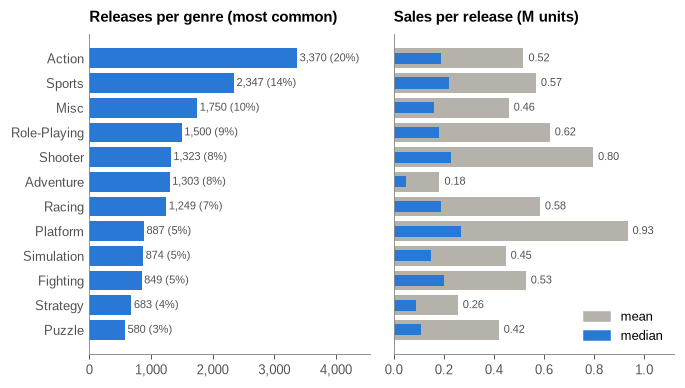

,Releases,Titles,Sales,Mean,Median,Release share,Sales share
Genre,,,,,,,
Action,3370,1958,1745.27,0.518,0.19,0.202,0.196
Sports,2347,1379,1332.00,0.568,0.22,0.140,0.149
Misc,1750,1330,803.18,0.459,0.16,0.105,0.090
Role-Playing,1500,1227,934.40,0.623,0.18,0.090,0.105
Shooter,1323,825,1052.94,0.796,0.23,0.079,0.118
Adventure,1303,1062,237.69,0.182,0.05,0.078,0.027
Racing,1249,773,728.90,0.584,0.19,0.075,0.082
Platform,887,588,828.08,0.934,0.27,0.053,0.093
Simulation,874,730,390.42,0.447,0.15,0.052,0.044


In [31]:
# @title Figure 1: releases and sales by genre

genre = games.groupby("Genre").agg(Releases=("Name", "size"), Titles=("Name", "nunique"),
                                   Sales=("Global_Sales", "sum"), Mean=("Global_Sales", "mean"),
                                   Median=("Global_Sales", "median"))
genre["Release share"] = genre["Releases"] / genre["Releases"].sum()
genre["Sales share"] = genre["Sales"] / genre["Sales"].sum()
genre = genre.sort_values("Releases")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_WIDTH, 3.6), sharey=True)
ax1.barh(genre.index, genre["Releases"], color=PRIMARY)
for y, (n, s) in enumerate(zip(genre["Releases"], genre["Release share"])):
    ax1.text(n + 40, y, f"{n:,} ({s:.0%})", va="center", fontsize=7.5, color=INK_SECONDARY)
ax1.set_title("Releases per genre (most common)")
ax1.set_xlim(0, genre["Releases"].max() * 1.35)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax2.barh(genre.index, genre["Mean"], color=MUTED)
ax2.barh(genre.index, genre["Median"], color=PRIMARY, height=0.45, label="median")
for y, m in enumerate(genre["Mean"]):
    ax2.text(m + 0.02, y, f"{m:.2f}", va="center", fontsize=7.5, color=INK_SECONDARY)
ax2.set_title("Sales per release (M units)")
ax2.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=MUTED), plt.Rectangle((0, 0), 1, 1, color=PRIMARY)],
           labels=["mean", "median"], loc="lower right")
ax2.set_xlim(0, genre["Mean"].max() * 1.2)
fig.tight_layout()
save_figure(fig, "fig01_genres")
plt.show()
genre.sort_values("Releases", ascending=False).round(3)

**Remark** ✅ **Action is by far the most common genre**: 3,370 releases (20 % of the catalogue), ahead of Sports (14 %) and Misc (10 %, party and music games). Frequency and performance are two different things, however:

- **Platform** games (Mario, Sonic) are only the 8th most common genre but sell the most **per release** (mean 0.93 M, median 0.27 M), followed by **Shooter** (0.80 M).
- **Adventure** is the 6th most common genre but the weakest seller (median 0.05 M, five times less than Platform): many small titles compete for a small audience. **Strategy** and **Puzzle** are in the same situation.
- The **median** is three to four times smaller than the mean in every genre: each genre lives on a few hits.

**For the company:** a genre where many releases compete (Action, Adventure) is a crowded market; a genre with a high median (Platform, Shooter, Sports) offers a better typical return per release.

## 10.2 Which platforms have the highest sales? (Q2)

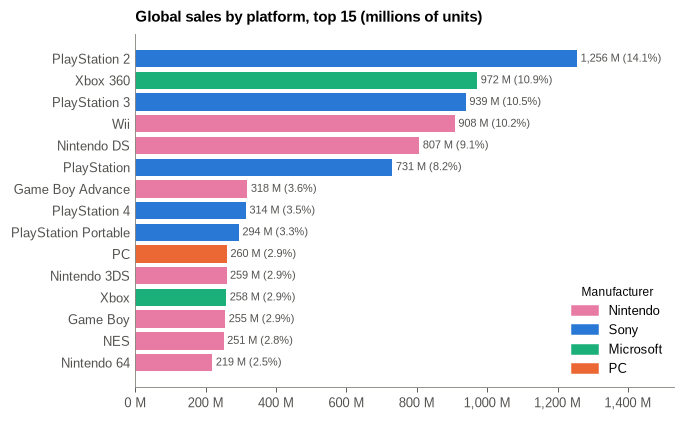

,Platform,Platform_Name,Manufacturer,Releases,Sales,First,Last,Share,Sales per release
16,PS2,PlayStation 2,Sony,2161,1255.64,2000,2011,0.141,0.581
28,X360,Xbox 360,Microsoft,1262,971.63,2005,2016,0.109,0.770
17,PS3,PlayStation 3,Sony,1329,939.43,2006,2016,0.105,0.707
26,Wii,Wii,Nintendo,1320,908.13,2006,2016,0.102,0.688
4,DS,Nintendo DS,Nintendo,2152,807.10,1985,2013,0.091,0.375
15,PS,PlayStation,Sony,1197,730.68,1994,2003,0.082,0.610
6,GBA,Game Boy Advance,Nintendo,822,318.50,2000,2007,0.036,0.387
18,PS4,PlayStation 4,Sony,393,314.23,2013,2016,0.035,0.800
19,PSP,PlayStation Portable,Sony,1209,294.30,2004,2015,0.033,0.243
13,PC,PC,PC,974,260.30,1985,2016,0.029,0.267


In [32]:
# @title Figure 2: global sales by platform (top 15)

plat = games.groupby(["Platform", "Platform_Name", "Manufacturer"]).agg(
    Releases=("Name", "size"), Sales=("Global_Sales", "sum"),
    First=("Year_of_Release", "min"), Last=("Year_of_Release", "max")).reset_index()
plat["Share"] = plat["Sales"] / plat["Sales"].sum()
plat["Sales per release"] = plat["Sales"] / plat["Releases"]
top_plat = plat.nlargest(15, "Sales").iloc[::-1]

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.9))
ax.barh(top_plat["Platform_Name"], top_plat["Sales"], color=[MAKER_COLORS[m] for m in top_plat["Manufacturer"]])
for y, (s, sh) in enumerate(zip(top_plat["Sales"], top_plat["Share"])):
    ax.text(s + 10, y, f"{s:,.0f} M ({sh:.1%})", va="center", fontsize=7.5, color=INK_SECONDARY)
ax.set_title("Global sales by platform, top 15 (millions of units)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.set_xlim(0, top_plat["Sales"].max() * 1.22)
makers = [m for m in MAKER_COLORS if m in set(top_plat["Manufacturer"])]
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=MAKER_COLORS[m]) for m in makers], labels=makers,
          loc="lower right", title="Manufacturer", title_fontsize=8)
fig.tight_layout()
save_figure(fig, "fig02_platforms")
plt.show()
plat.sort_values("Sales", ascending=False).head(10).round(3)

In [33]:
# @title Sales by manufacturer

maker = games.groupby("Manufacturer")["Global_Sales"].agg(["size", "sum"]).rename(columns={"size": "Releases", "sum": "Sales"})
maker["Share"] = maker["Sales"] / maker["Sales"].sum()
maker.sort_values("Sales", ascending=False).round(3)

,Releases,Sales,Share
Manufacturer,,,
Sony,6721,3588.40,0.402
Nintendo,6271,3499.79,0.392
Microsoft,2333,1389.33,0.156
PC,974,260.30,0.029
Other,157,100.23,0.011
Sega,259,79.83,0.009


**Remark** ✅ The **PlayStation 2** is the best-selling platform of the dataset (1,256 M units, 14.1 % of all units), ahead of the Xbox 360 (972 M), PS3 (939 M), Wii (908 M) and DS (807 M). The top 5 are all consoles of the **2000s generation**, the peak of retail sales.

- By manufacturer, **Sony** (40 % of units) and **Nintendo** (39 %) share four fifths of the market; Microsoft follows with 16 %, PC with 3 %.
- The **PS4**, launched in 2013, already ranks 8th (314 M) after only four years in the file: it is the leading platform of the most recent period.
- The **DS** and the **PS2** have the largest catalogues (more than 2,150 releases each): a large installed base attracts many publishers.

**For the company:** sales follow the installed base of the platform. A publisher should be present on the leading platforms of the current generation (PS4, Xbox One, 3DS in this file) rather than on the record holders of the past.

## 10.3 Which publishers have the highest total sales? (Q3)

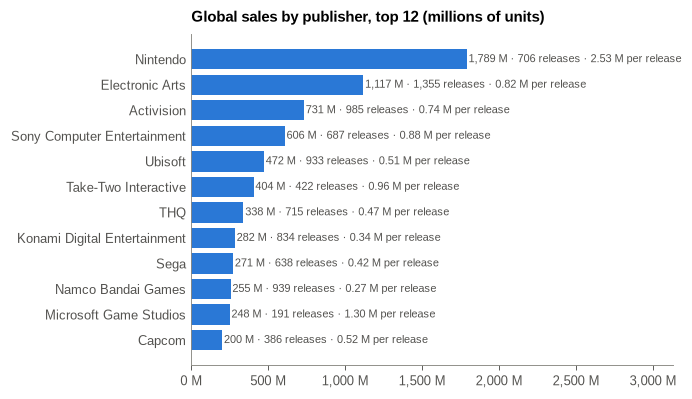

Publishers in the file: 581 | share of units of the top 10: 70.3%


,Releases,Sales,Mean,Share
Publisher,,,,
Nintendo,706,1788.81,2.534,0.201
Electronic Arts,1355,1116.96,0.824,0.125
Activision,985,731.16,0.742,0.082
Sony Computer Entertainment,687,606.48,0.883,0.068
Ubisoft,933,471.61,0.505,0.053
Take-Two Interactive,422,403.82,0.957,0.045
THQ,715,338.44,0.473,0.038
Konami Digital Entertainment,834,282.39,0.339,0.032
Sega,638,270.83,0.424,0.030


In [34]:
# @title Figure 3: top 12 publishers by global sales

pub = games.groupby("Publisher").agg(Releases=("Name", "size"), Sales=("Global_Sales", "sum"),
                                     Mean=("Global_Sales", "mean"))
pub["Share"] = pub["Sales"] / pub["Sales"].sum()
pub = pub.sort_values("Sales", ascending=False)
top_pub = pub.head(12).iloc[::-1]

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.7))
ax.barh(top_pub.index, top_pub["Sales"], color=PRIMARY)
for y, (s, n, m) in enumerate(zip(top_pub["Sales"], top_pub["Releases"], top_pub["Mean"])):
    ax.text(s + 12, y, f"{s:,.0f} M · {n:,} releases · {m:.2f} M per release", va="center", fontsize=7.5, color=INK_SECONDARY)
ax.set_title("Global sales by publisher, top 12 (millions of units)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.set_xlim(0, top_pub["Sales"].max() * 1.75)
fig.tight_layout()
save_figure(fig, "fig03_publishers")
plt.show()
print(f"Publishers in the file: {len(pub)} | share of units of the top 10: {pub['Sales'].head(10).sum() / total_units:.1%}")
pub.head(10).round(3)

**Remark** ✅ **Nintendo** leads with **1,789 M units (20 % of the market)**, followed by Electronic Arts (1,117 M), Activision (731 M), Sony Computer Entertainment (606 M) and Ubisoft (472 M). Two business models appear:

- **Nintendo** publishes few releases (706) but sells **2.53 M per release**, five times the market average: it publishes for its own consoles and owns the strongest franchises (Mario, Pokémon, Wii Sports).
- **Electronic Arts** publishes almost twice as many releases (1,355) at 0.82 M each: a **volume** model built on annual franchises (FIFA, Madden, Need for Speed) released on every platform.
- **Namco Bandai** and **Konami** have more releases than Nintendo but sell 0.27-0.34 M per release.

The market is **concentrated**: the 10 largest publishers (of 581) hold **70 %** of all units.

## 10.4 What are the best-selling games? (Q4)

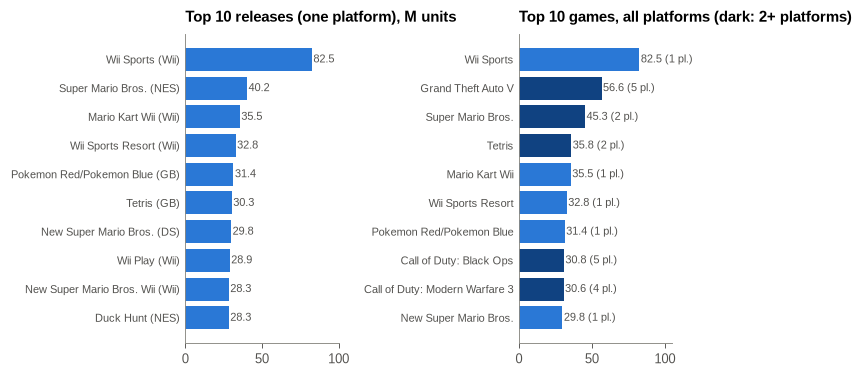

,Name,Platform,Year_of_Release,Publisher,Global_Sales
0,Wii Sports,Wii,2006,Nintendo,82.53
1,Super Mario Bros.,NES,1985,Nintendo,40.24
2,Mario Kart Wii,Wii,2008,Nintendo,35.52
3,Wii Sports Resort,Wii,2009,Nintendo,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Nintendo,31.37
5,Tetris,GB,1989,Nintendo,30.26
6,New Super Mario Bros.,DS,2006,Nintendo,29.80
7,Wii Play,Wii,2006,Nintendo,28.92
8,New Super Mario Bros. Wii,Wii,2009,Nintendo,28.32
9,Duck Hunt,NES,1984,Nintendo,28.31


In [35]:
# @title Figure 4: best-selling releases and best-selling games (all platforms)

top_rel = games.nlargest(10, "Global_Sales")[["Name", "Platform", "Year_of_Release", "Publisher", "Global_Sales"]]
titles = games.groupby("Name").agg(Sales=("Global_Sales", "sum"), Platforms=("Platform", "nunique"),
                                   Publisher=("Publisher", "first")).sort_values("Sales", ascending=False)
top_tit = titles.head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_WIDTH, 3.5))
r = top_rel.iloc[::-1]
ax1.barh(r["Name"] + " (" + r["Platform"] + ")", r["Global_Sales"], color=PRIMARY)
for y, s in enumerate(r["Global_Sales"]):
    ax1.text(s + 1, y, f"{s:.1f}", va="center", fontsize=7.5, color=INK_SECONDARY)
ax1.set_title("Top 10 releases (one platform), M units")
ax1.set_xlim(0, 100)
t = top_tit.iloc[::-1]
ax2.barh(t.index, t["Sales"], color=[PRIMARY if p == 1 else "#104281" for p in t["Platforms"]])
for y, (s, p) in enumerate(zip(t["Sales"], t["Platforms"])):
    ax2.text(s + 1, y, f"{s:.1f} ({p} pl.)", va="center", fontsize=7.5, color=INK_SECONDARY)
ax2.set_title("Top 10 games, all platforms (dark: 2+ platforms)")
ax2.set_xlim(0, 105)
for a in (ax1, ax2):
    a.tick_params(axis="y", labelsize=7)
fig.tight_layout()
save_figure(fig, "fig04_best_sellers")
plt.show()
top_rel

In [36]:
# @title The 10 best-selling games, all platforms together

top_tit

,Sales,Platforms,Publisher
Name,,,
Wii Sports,82.53,1,Nintendo
Grand Theft Auto V,56.57,5,Take-Two Interactive
Super Mario Bros.,45.31,2,Nintendo
Tetris,35.84,2,Nintendo
Mario Kart Wii,35.52,1,Nintendo
Wii Sports Resort,32.77,1,Nintendo
Pokemon Red/Pokemon Blue,31.37,1,Nintendo
Call of Duty: Black Ops,30.82,5,Activision
Call of Duty: Modern Warfare 3,30.59,4,Activision


**Remark** ✅ **Wii Sports** (82.5 M units) is by far the best-selling release, and **all of the top 10 releases are Nintendo games** on Nintendo hardware (Wii, NES, GB, DS). Many of them were **bundled with the console** (Wii Sports, Super Mario Bros., Duck Hunt, Tetris): their sales follow the console sales.

Counting a game on all its platforms changes the picture: **Grand Theft Auto V** becomes the **second best-selling game** (56.6 M units on 5 platforms), and *Call of Duty: Black Ops* and *Modern Warfare 3* enter the top 10 (about 31 M each on 4-5 platforms).

**For the company:** a third-party publisher cannot rely on console bundles; its route to the top is the **multi-platform blockbuster**. GTA V sold 56.6 M units because it was released on 5 platforms across two console generations.

## 10.5 How have game sales changed over the years? (Q5)

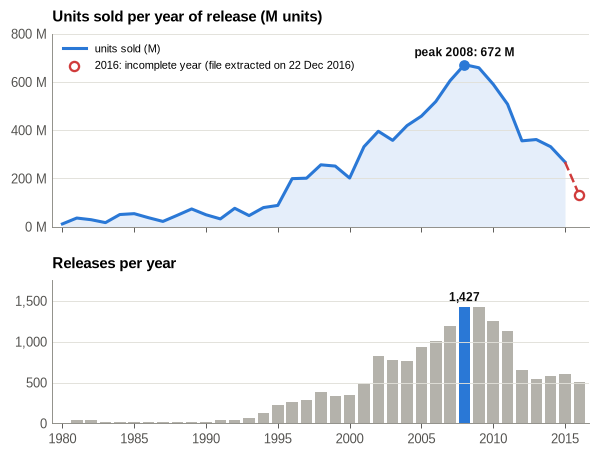

,Releases,Sales,Sales per release
Year,,,
1985,14,53.94,3.85
1990,16,49.39,3.09
1995,219,88.11,0.40
2000,350,201.58,0.58
2005,939,458.31,0.49
2008,1427,671.79,0.47
2009,1426,658.88,0.46
2010,1255,590.59,0.47
2012,652,355.84,0.55


In [37]:
# @title Figure 5: units sold and releases per year (1980-2016)

yearly = dated.groupby("Year").agg(Releases=("Name", "size"), Sales=("Global_Sales", "sum"))
yearly["Sales per release"] = yearly["Sales"] / yearly["Releases"]
peak = yearly["Sales"].idxmax()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(FIG_WIDTH, 4.6), sharex=True, gridspec_kw={"height_ratios": [1.35, 1], "hspace": 0.32})
full = yearly.loc[:2015]
ax1.fill_between(full.index, full["Sales"], color=PRIMARY, alpha=0.12, lw=0)
ax1.plot(full.index, full["Sales"], color=PRIMARY, lw=2, label="units sold (M)")
ax1.plot([2015, 2016], yearly.loc[[2015, 2016], "Sales"], color=CRITICAL, lw=1.6, ls="--")
ax1.scatter([2016], [yearly.loc[2016, "Sales"]], s=36, facecolor="white", edgecolor=CRITICAL, lw=1.5, zorder=3,
            label="2016: incomplete year (file extracted on 22 Dec 2016)")
ax1.scatter([peak], [yearly.loc[peak, "Sales"]], s=36, color=PRIMARY, zorder=3)
ax1.text(peak, yearly.loc[peak, "Sales"] + 35, f"peak {peak}: {yearly.loc[peak, 'Sales']:.0f} M", ha="center", fontsize=8,
         fontweight="bold", color=INK)
ax1.set_ylim(0, 800)
ax1.set_title("Units sold per year of release (M units)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax1.grid(axis="y")
ax1.legend(loc="upper left", fontsize=7.5)
colors = [PRIMARY if y == peak else MUTED for y in yearly.index]
ax2.bar(yearly.index, yearly["Releases"], color=colors, width=0.8)
ax2.text(peak, yearly.loc[peak, "Releases"] + 70, f"{yearly.loc[peak, 'Releases']:,}", ha="center", fontsize=8,
         fontweight="bold", color=INK)
ax2.set_ylim(0, 1750)
ax2.set_title("Releases per year")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax2.grid(axis="y")
ax2.set_xlim(1979.3, 2016.7)
save_figure(fig, "fig05_sales_over_years")
plt.show()
yearly.loc[[1985, 1990, 1995, 2000, 2005, 2008, 2009, 2010, 2012, 2014, 2015, 2016]].round(2)

**Remark** ✅ The market went through **three phases**:

1. **1980-1995, a small market** (fewer than 100 M units a year), dominated by Nintendo.
2. **1996-2008, fast growth**: units multiplied by 7 with the PlayStation, PS2, DS and Wii, up to a **peak in 2008** (672 M units and 1,427 releases).
3. **2009-2016, decline** of tracked retail sales: 268 M units in 2015, 60 % below the peak.

The decline is real for **retail units**, but it must not be read as a collapse of the gaming industry: this period is the rise of **digital downloads, mobile and free-to-play games**, which VGChartz does not track; and **2016 is incomplete** (the file stops on 22 December and recent games keep selling for years, see section 12). Releases and units fell at the same pace between 2008 and 2015 (-58 % and -60 %): fewer games are published for retail, and each one sells about as much as before (0.44 to 0.57 M units per release).

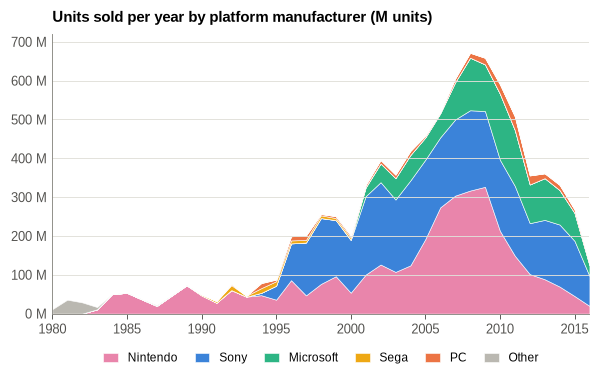

Manufacturer,Nintendo,Sony,Microsoft,Sega,PC,Other
Year,,,,,,
1995,35.8,35.9,0.0,11.6,4.2,0.6
2000,53.8,135.4,1.0,6.0,4.7,0.7
2005,191.9,204.5,57.4,0.0,4.4,0.0
2008,316.9,206.8,135.4,0.0,12.6,0.0
2010,213.2,183.0,170.1,0.0,24.4,0.0
2015,45.3,142.2,72.0,0.0,8.6,0.0


In [38]:
# @title Figure 6: units sold per year by manufacturer (console generations)

by_maker = dated.pivot_table(index="Year", columns="Manufacturer", values="Global_Sales", aggfunc="sum", fill_value=0)
by_maker = by_maker[[m for m in MAKER_COLORS if m in by_maker.columns]]

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.3))
ax.stackplot(by_maker.index, by_maker.T.values, labels=by_maker.columns,
             colors=[MAKER_COLORS[m] for m in by_maker.columns], alpha=0.92, lw=0.4, edgecolor="white")
ax.set_title("Units sold per year by platform manufacturer (M units)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.set_ylim(0, 720)
ax.set_xlim(1980, 2016)
ax.grid(axis="y")
ax.legend(ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.1), fontsize=8, handlelength=1.2, columnspacing=1.4)
save_figure(fig, "fig06_manufacturers_over_years")
plt.show()
by_maker.loc[[1995, 2000, 2005, 2008, 2010, 2015]].round(1)

**Remark** ✅ The market is driven by **console generations**: Sony takes the lead with the PlayStation (1995) and the PS2 (2000-2005), Nintendo's peak comes from the **Wii and DS** (2006-2010), and Microsoft grows with the Xbox 360. Sega disappears from hardware after the Dreamcast (2001). Each generation lasts **6 to 8 years**, and the sales of a platform peak 3 to 5 years after its launch.

## 10.6 Which regions generate the highest sales? (Q6)

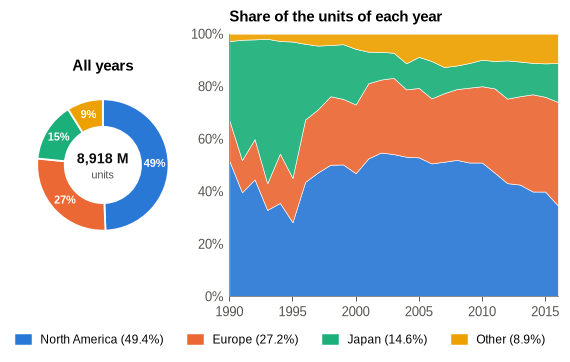

,M units,Share
North America,4400.8,0.494
Europe,2424.1,0.272
Japan,1297.4,0.146
Other,791.3,0.089


In [39]:
# @title Figure 7: share of units by region, overall and over time

region_cols = {"NA_Sales": "North America", "EU_Sales": "Europe", "JP_Sales": "Japan", "Other_Sales": "Other"}
region_total = games[list(region_cols)].sum().rename(region_cols)
region_share = region_total / region_total.sum()
by_year = dated.groupby("Year")[list(region_cols)].sum().rename(columns=region_cols)
share_year = by_year.div(by_year.sum(axis=1), axis=0).loc[1990:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_WIDTH, 3.1), gridspec_kw={"width_ratios": [1, 2], "wspace": 0.18})
colors = [REGION_COLORS[r] for r in region_total.index]
wedges, _ = ax1.pie(region_total, colors=colors, startangle=90, counterclock=False,
                    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=1.2))
for w, s_ in zip(wedges, region_share):
    ang = np.deg2rad((w.theta2 + w.theta1) / 2)
    ax1.text(0.79 * np.cos(ang), 0.79 * np.sin(ang), f"{s_:.0%}", ha="center", va="center", fontsize=7.5,
             fontweight="bold", color="white")
ax1.text(0, 0.08, f"{total_units:,.0f} M", ha="center", va="center", fontsize=9, fontweight="bold", color=INK)
ax1.text(0, -0.16, "units", ha="center", va="center", fontsize=7.5, color=INK_SECONDARY)
ax1.set_title("All years", loc="center")
ax2.stackplot(share_year.index, share_year.T.values * 100, colors=colors, alpha=0.92, lw=0.4, edgecolor="white")
ax2.set_ylim(0, 100)
ax2.set_xlim(1990, 2016)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_title("Share of the units of each year")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
labels = [f"{r} ({s_:.1%})" for r, s_ in region_share.items()]
fig.legend(handles, labels, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 0.03), fontsize=8, handlelength=1.2)
save_figure(fig, "fig07_regions")
plt.show()
pd.DataFrame({"M units": region_total.round(1), "Share": region_share.round(3)})

In [40]:
# @title Regional shares by decade

dated["Decade"] = (dated["Year"] // 10 * 10).astype(str) + "s"
decade_share = dated.groupby("Decade")[list(region_cols)].sum().rename(columns=region_cols)
decade_share.div(decade_share.sum(axis=1), axis=0).round(3)

,North America,Europe,Japan,Other
Decade,,,,
1980s,0.626,0.083,0.272,0.019
1990s,0.451,0.221,0.291,0.037
2000s,0.520,0.270,0.111,0.100
2010s,0.444,0.331,0.120,0.105


**Remark** ✅ **North America generates half of all units** (4,401 M, 49.4 %), ahead of **Europe** (27.2 %), **Japan** (14.6 %) and the rest of the world (8.9 %). The balance has moved over time:

- **Japan** weighed 27-29 % of units in the 1980s-1990s (52 % in 1995, the year of the PlayStation and Saturn in Japan) but only **10-15 % since 2005**.
- **Europe** rose steadily, from 8 % in the 1980s to **33 % in the 2010s**, and in 2016 it is the **first region** of the year (39 % vs 35 % for North America).

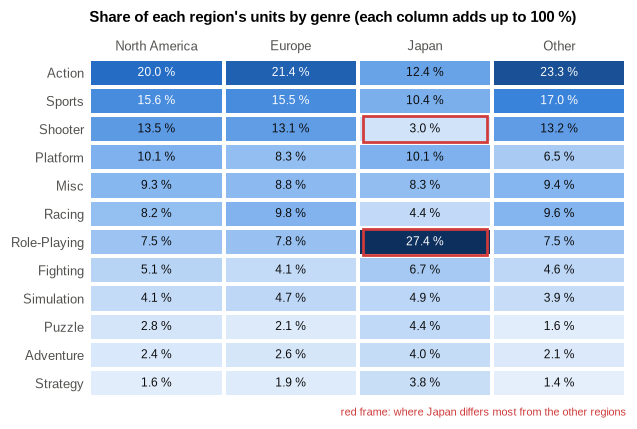

,North America,Europe,Japan,Other
Genre,,,,
Action,20.0,21.4,12.4,23.3
Sports,15.6,15.5,10.4,17.0
Shooter,13.5,13.1,3.0,13.2
Platform,10.1,8.3,10.1,6.5
Misc,9.3,8.8,8.3,9.4
Racing,8.2,9.8,4.4,9.6
Role-Playing,7.5,7.8,27.4,7.5
Fighting,5.1,4.1,6.7,4.6
Simulation,4.1,4.7,4.9,3.9


In [41]:
# @title Figure 8: what each region buys (share of the region's units by genre)

gen_reg = games.groupby("Genre")[list(region_cols)].sum().rename(columns=region_cols)
gen_reg = gen_reg.div(gen_reg.sum(axis=0), axis=1) * 100
gen_reg = gen_reg.sort_values("North America", ascending=False)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 4.0))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("ramp", ["#f4f8fd", "#86b6ef", "#2a78d6", "#0a2a57"])
ax.pcolormesh(gen_reg.values, cmap=cmap, vmin=0, vmax=28, edgecolors="white", linewidth=1.5)
ax.set_xticks(np.arange(4) + 0.5, gen_reg.columns)
ax.set_yticks(np.arange(len(gen_reg)) + 0.5, gen_reg.index)
ax.invert_yaxis()
ax.xaxis.tick_top()
ax.tick_params(length=0)
for i in range(gen_reg.shape[0]):
    for j in range(gen_reg.shape[1]):
        v = gen_reg.values[i, j]
        ax.text(j + 0.5, i + 0.5, f"{v:.1f} %", ha="center", va="center", fontsize=8, color="white" if v > 14 else INK)
for highlighted in ("Role-Playing", "Shooter"):   # the two cells that make Japan a different market
    i = list(gen_reg.index).index(highlighted)
    ax.add_patch(plt.Rectangle((2.04, i + 0.04), 0.92, 0.92, fill=False, edgecolor=CRITICAL, lw=1.8))
for s_ in ax.spines.values():
    s_.set_visible(False)
ax.set_title("Share of each region's units by genre (each column adds up to 100 %)", pad=24)
ax.text(4, len(gen_reg) + 0.35, "red frame: where Japan differs most from the other regions", ha="right", va="top",
        fontsize=7.5, color=CRITICAL)
save_figure(fig, "fig08_genre_by_region")
plt.show()
gen_reg.round(1)

**Remark** ✅ **Japan is a different market.** Role-Playing games make **27.4 %** of Japanese units, against 7.5 % in North America and 7.8 % in Europe; Shooters make only **3.0 %** in Japan, against 13.5 % in North America. North America, Europe and the rest of the world buy the same mix (Action, Sports, Shooter), with **Racing** a little stronger in Europe.

**For the company:** one global product does not fit all regions. A shooter or sports game targets the West; a role-playing game is the natural entry into Japan; and Europe, now as large as North America for new releases, deserves the same launch effort (localisation, marketing).

## 10.7 Is there a relationship between game ratings and sales? (Q7)

The analysis uses the **8,135 releases with a critic score** (48.7 % of the releases, but 62.9 % of the units: reviewed games are the more visible ones) and the 7,588 with a user score.

Releases with a critic score: 8,135 (48.7% of releases, 62.9% of units)


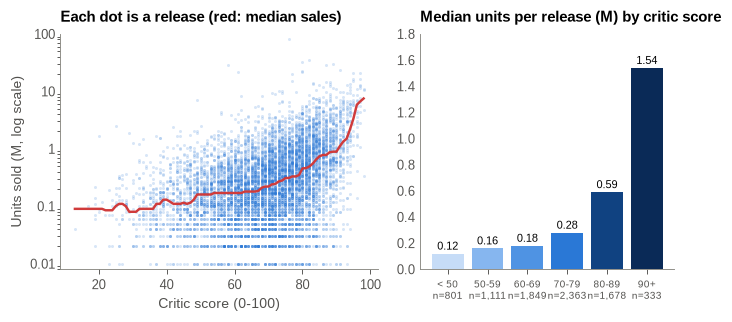

,size,median,mean
Critic_Band,,,
< 50,801,0.12,0.230
50-59,1111,0.16,0.297
60-69,1849,0.18,0.367
70-79,2363,0.28,0.600
80-89,1678,0.59,1.223
90+,333,1.54,2.835


In [42]:
# @title Figure 9: critic score and sales

scored = games.dropna(subset=["Critic_Score"]).copy()
print(f"Releases with a critic score: {len(scored):,} ({len(scored) / len(games):.1%} of releases, "
      f"{scored['Global_Sales'].sum() / total_units:.1%} of units)")
band = scored.groupby("Critic_Band", observed=True)["Global_Sales"].agg(["size", "median", "mean"])
band = band.loc[band_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_WIDTH, 3.0), gridspec_kw={"width_ratios": [1.25, 1]})
ax1.scatter(scored["Critic_Score"], scored["Global_Sales"], s=4, alpha=0.18, color=PRIMARY, lw=0, rasterized=True)
ax1.set_yscale("log")
ax1.set_ylim(0.008, 100)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
by_score = scored.groupby("Critic_Score")["Global_Sales"].median()
ax1.plot(by_score.index, by_score.rolling(5, center=True, min_periods=1).median(), color=CRITICAL, lw=1.6,
         label="median sales (rolling)")
ax1.set_xlabel("Critic score (0-100)")
ax1.set_ylabel("Units sold (M, log scale)")
ax1.set_title("Each dot is a release (red: median sales)")
ax2.bar(band.index, band["median"], color=RAMP[:6])
for x, (m, n) in enumerate(zip(band["median"], band["size"])):
    ax2.text(x, m + 0.03, f"{m:.2f}", ha="center", fontsize=7.5)
ax2.set_xticks(range(len(band)), [f"{b}\nn={n:,}" for b, n in zip(band.index, band["size"])])
ax2.set_title("Median units per release (M) by critic score")
ax2.set_ylim(0, 1.8)
ax2.tick_params(axis="x", labelsize=6.8)
fig.tight_layout()
save_figure(fig, "fig09_critic_score_sales")
plt.show()
band.round(3)

**Remark** ✅ **Better-reviewed games sell more, and the effect accelerates at the top.** The median release sells 0.12 M units below a critic score of 50, 0.28 M at 70-79, **0.59 M at 80-89** and **1.54 M at 90 or more**: from the lowest to the highest band, typical sales are multiplied by **13**. The cloud of dots is very wide, however: some poorly rated games sell millions (licensed and party games), and many excellent games sell little. The score shifts the odds; it does not guarantee a hit.

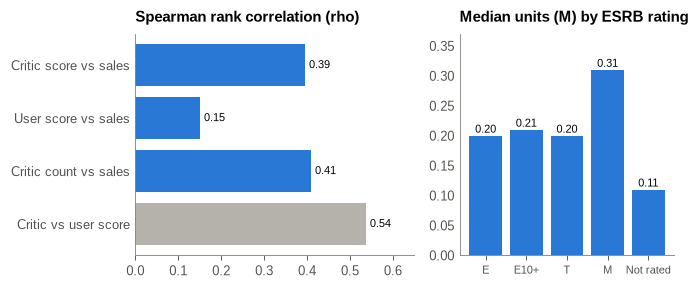

Critic score vs sales    0.394
User score vs sales      0.150
Critic count vs sales    0.409
Critic vs user score     0.536


,size,mean,median
Rating,,,
E,3993,0.611,0.20
E10+,1419,0.462,0.21
T,2961,0.505,0.20
M,1563,0.943,0.31
Not rated,6770,0.421,0.11


In [43]:
# @title Figure 10: critics vs players, and the ESRB rating

both = games.dropna(subset=["Critic_Score", "User_Score"])
rho = pd.Series({
    "Critic score vs sales": stats.spearmanr(scored["Critic_Score"], scored["Global_Sales"])[0],
    "User score vs sales": stats.spearmanr(games["User_Score"].dropna(), games.loc[games["User_Score"].notna(), "Global_Sales"])[0],
    "Critic count vs sales": stats.spearmanr(scored["Critic_Count"], scored["Global_Sales"])[0],
    "Critic vs user score": stats.spearmanr(both["Critic_Score"], both["User_Score"])[0],
})
esrb = games[games["Rating"].isin(["E", "E10+", "T", "M", "Not rated"])].groupby("Rating")["Global_Sales"].agg(["size", "mean", "median"])
esrb = esrb.loc[["E", "E10+", "T", "M", "Not rated"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.7), gridspec_kw={"width_ratios": [1.3, 1]})
ax1.barh(rho.index[::-1], rho.values[::-1], color=[MUTED, PRIMARY, PRIMARY, PRIMARY])   # critic vs user (not a sales link) in grey
for y, v in enumerate(rho.values[::-1]):
    ax1.text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=7.5)
ax1.set_xlim(0, 0.65)
ax1.set_title("Spearman rank correlation (rho)")
ax2.bar(esrb.index, esrb["median"], color=PRIMARY)
for x, (m, n) in enumerate(zip(esrb["median"], esrb["size"])):
    ax2.text(x, m + 0.005, f"{m:.2f}", ha="center", fontsize=7.5)
ax2.set_title("Median units (M) by ESRB rating")
ax2.set_ylim(0, 0.37)
ax2.tick_params(axis="x", labelsize=7.5)
fig.tight_layout()
save_figure(fig, "fig10_scores_esrb")
plt.show()
print(rho.round(3).to_string())
esrb.round(3)

**Remark** ✅ **The press matters more than the players.** The rank correlation with sales is **0.39 for the critic score** but only **0.15 for the user score**, although the two scores agree with each other (ρ = 0.54). Two explanations are consistent with the data: critic reviews are published **before or at the launch**, when most copies are sold, whereas user scores accumulate later; and user scores of popular games are sometimes pulled down by protest votes.

The **number of critics** is as strongly linked to sales as the score itself (ρ = 0.41): big games get more reviews. Section 11 checks whether the score still matters once this visibility effect is removed.

By ESRB rating, **M (Mature)** games have the highest median (0.31 M units, driven by shooters and GTA), and **Not rated** releases the lowest (0.11 M): mostly older or smaller games, never submitted to the ESRB.

## 10.8 Additional analysis: a hit-driven market

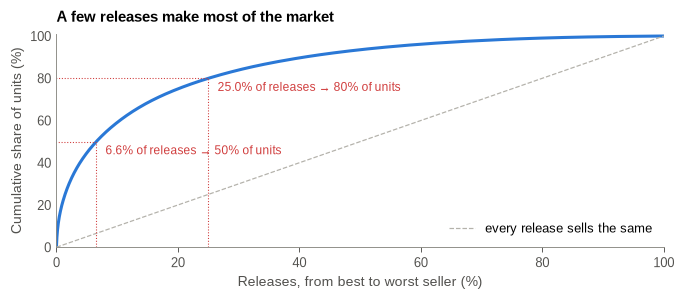

Half of all units come from 6.6% of the releases; 80 % from 25.0%.
Releases under 0.1 M units: 35.2%


In [44]:
# @title Figure 11: concentration of sales (Lorenz-type curve)

sorted_sales = games["Global_Sales"].sort_values(ascending=False).to_numpy()
cum_share = sorted_sales.cumsum() / sorted_sales.sum()
rel_share = np.arange(1, len(sorted_sales) + 1) / len(sorted_sales)
half = rel_share[np.searchsorted(cum_share, 0.5)]
eighty = rel_share[np.searchsorted(cum_share, 0.8)]

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 2.8))
ax.plot(rel_share * 100, cum_share * 100, color=PRIMARY, lw=2)
ax.plot([0, 100], [0, 100], color=MUTED, lw=0.8, ls="--", label="every release sells the same")
for share, level in ((half, 50), (eighty, 80)):
    ax.plot([share * 100, share * 100, 0], [0, level, level], color=CRITICAL, lw=0.7, ls=":")
    ax.text(share * 100 + 1.5, level - 6, f"{share:.1%} of releases → {level}% of units", fontsize=8, color=CRITICAL)
ax.set_xlabel("Releases, from best to worst seller (%)")
ax.set_ylabel("Cumulative share of units (%)")
ax.set_title("A few releases make most of the market")
ax.legend(loc="lower right")
ax.set_xlim(0, 100)
ax.set_ylim(0, 101)
fig.tight_layout()
save_figure(fig, "fig11_concentration")
plt.show()
print(f"Half of all units come from {half:.1%} of the releases; 80 % from {eighty:.1%}.")
print(f"Releases under 0.1 M units: {(games['Global_Sales'] < 0.1).mean():.1%}")

**Remark** ✅ The video game market is a **hit-driven business**: **6.6 % of the releases make half of all units** and one quarter makes 80 %, while 35 % of the releases sell fewer than 100,000 copies.

**For the company:** a portfolio needs a few strong titles to carry many small ones. Average figures are misleading for planning; budgets and forecasts should be built on the median and on the probability of a hit.

<a name="statistical-tests"></a>
# 11. Statistical Tests

Sales are far from normal (very skewed), so the tests are **rank-based** (Spearman, Kruskal-Wallis), which do not assume normality. With thousands of releases even weak effects are "significant"; the **size** of the effect (ρ, ε²) is what matters.

In [45]:
# @title Test 1: rank correlations with sales, with 95 % bootstrap intervals

rng = np.random.default_rng(42)


def spearman_ci(x: pd.Series, y: pd.Series, n_boot: int = 1000) -> tuple:
    """
    Spearman correlation with a 95 % percentile bootstrap confidence interval.

    Args:
        x: First variable.
        y: Second variable.
        n_boot: Number of bootstrap samples.

    Returns:
        (rho, lower bound, upper bound, p-value, n).
    """
    x, y = np.asarray(x, float), np.asarray(y, float)
    rho, p = stats.spearmanr(x, y)
    idx = rng.integers(0, len(x), (n_boot, len(x)))
    boots = [stats.spearmanr(x[i], y[i])[0] for i in idx]
    return rho, np.percentile(boots, 2.5), np.percentile(boots, 97.5), p, len(x)


u = games.dropna(subset=["User_Score"])
tests = {
    "Critic score": spearman_ci(scored["Critic_Score"], scored["Global_Sales"]),
    "User score": spearman_ci(u["User_Score"], u["Global_Sales"]),
    "Critic count": spearman_ci(scored["Critic_Count"], scored["Global_Sales"]),
    "Year of release": spearman_ci(dated["Year"], dated["Global_Sales"]),
}
corr_table = pd.DataFrame(tests, index=["rho", "CI low", "CI high", "p-value", "n"]).T
corr_table["n"] = corr_table["n"].astype(int)
corr_table.round(3)

,rho,CI low,CI high,p-value,n
Critic score,0.394,0.375,0.415,0.0,8135
User score,0.150,0.128,0.171,0.0,7588
Critic count,0.409,0.390,0.428,0.0,8135
Year of release,-0.161,-0.176,-0.145,0.0,16443


In [46]:
# @title Test 2: does the critic score still matter once visibility (critic count) is removed?

def partial_spearman(frame: pd.DataFrame, x: str, y: str, control: str) -> float:
    """
    Partial Spearman correlation of x and y controlling for one variable.

    The three variables are ranked, the control is regressed out of x and y,
    and the residuals are correlated.

    Args:
        frame: Table with the three columns.
        x: First variable.
        y: Second variable.
        control: Variable whose effect is removed.

    Returns:
        The partial rank correlation.
    """
    r = frame[[x, y, control]].rank()
    design = np.column_stack([np.ones(len(r)), r[control]])
    res_x = r[x] - design @ np.linalg.lstsq(design, r[x], rcond=None)[0]
    res_y = r[y] - design @ np.linalg.lstsq(design, r[y], rcond=None)[0]
    return np.corrcoef(res_x, res_y)[0, 1]


partial = partial_spearman(scored, "Critic_Score", "Global_Sales", "Critic_Count")
print(f"Critic score vs sales, raw rho                : {tests['Critic score'][0]:.3f}")
print(f"Critic score vs sales, controlling critic count: {partial:.3f}")

per_genre = scored.groupby("Genre").apply(lambda g: stats.spearmanr(g["Critic_Score"], g["Global_Sales"])[0])
print("\nRho within each genre (the link holds in all 12 genres):")
print(per_genre.sort_values().round(2).to_string())

Critic score vs sales, raw rho                : 0.394
Critic score vs sales, controlling critic count: 0.262

Rho within each genre (the link holds in all 12 genres):
Genre
Adventure       0.13
Strategy        0.28
Simulation      0.29
Misc            0.29
Racing          0.32
Puzzle          0.35
Platform        0.38
Action          0.42
Role-Playing    0.45
Shooter         0.47
Sports          0.47
Fighting        0.50


In [47]:
# @title Test 3: Kruskal-Wallis, do sales differ between critic bands, genres and regions?

def kruskal_effect(groups: list) -> tuple:
    """
    Kruskal-Wallis test with its effect size epsilon squared.

    Args:
        groups: List of samples, one per group.

    Returns:
        (H statistic, p-value, epsilon squared).
    """
    h, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    return h, p, h / (n - 1)


kw = pd.DataFrame({
    "Critic band": kruskal_effect([g["Global_Sales"].values for _, g in scored.groupby("Critic_Band")]),
    "Genre": kruskal_effect([g["Global_Sales"].values for _, g in games.groupby("Genre")]),
    "Manufacturer": kruskal_effect([g["Global_Sales"].values for _, g in games.groupby("Manufacturer")]),
    "ESRB rating": kruskal_effect([g["Global_Sales"].values for _, g in games.groupby("Rating") if len(g) > 20]),
}, index=["H", "p-value", "epsilon squared"]).T
kw.round(4)

,H,p-value,epsilon squared
Critic band,1291.1103,0.0,0.1587
Genre,996.2765,0.0,0.0596
Manufacturer,560.2073,0.0,0.0335
ESRB rating,743.0224,0.0,0.0445


**Remark** ✅ The tests confirm the patterns of section 10 and measure their strength:

| Relationship | Result | Reading |
|---|---|---|
| Critic score vs sales | ρ = 0.39, 95 % CI about [0.37, 0.41] | **moderate**, the strongest of the dataset |
| ... controlling for the number of critics | partial ρ = 0.26 | the link **survives** the visibility effect: it is not only that big games get reviewed |
| ... within each genre | ρ from 0.13 (Adventure) to 0.50 (Fighting) | positive in **all 12 genres** |
| User score vs sales | ρ = 0.15 | **weak** |
| Year of release vs sales | ρ = -0.16 | recent releases sell slightly **less** each: the market grew by the number of releases, and the oldest releases of the file are mostly the hits that were remembered |
| Sales by critic band | ε² = 0.16 | the score band explains a large share of the rank differences |
| Sales by genre, manufacturer, ESRB rating | ε² from 0.03 to 0.06 | real but **small** differences: the genre alone does not make a hit |

These are **associations**, not causes: a large budget can produce both a better game (higher score) and a larger marketing campaign (more sales). Still, the critic score is the best single predictor of sales in this file.

<a name="current-gen"></a>
# 12. After 2016: the PS4 and Xbox One Generation

The two console files give a later picture of the current generation. They are **not merged** with the main file (different snapshot, different genre names such as *Action-Adventure* or *MMO*); they are used to answer two questions: what does the market of the PS4 and Xbox One look like, and how much does a game keep selling after its first years?

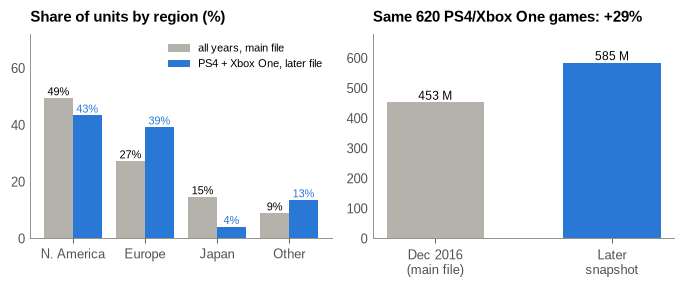

Releases with sales in the console files: 1,135 (864.7 M units)
Matched with the main file: 620 of 640 PS4/Xbox One releases
Median growth per game: 22%


,All years (main),PS4 + Xbox One (later)
North America,0.494,0.433
Europe,0.272,0.391
Japan,0.146,0.041
Other,0.089,0.135


In [48]:
# @title Figure 12: the current generation by region, and late sales of established games

cg_regions = current[["NA", "EU", "JP", "Other"]].sum().rename({"NA": "North America", "EU": "Europe", "JP": "Japan"})
cg_share = cg_regions / cg_regions.sum()
all_share = region_share.reindex(cg_share.index)

# same release in both files: match on a simplified title and the platform
def simple(title: str) -> str:
    """
    Simplifies a title to match the two sources (lower case, letters and digits only).

    Args:
        title: The game title.

    Returns:
        The simplified key.
    """
    return re.sub(r"[^a-z0-9]", "", title.lower())


old = games[games["Platform"].isin(["PS4", "XOne"])][["Name", "Platform", "Global_Sales"]].copy()
old["key"] = old["Name"].map(simple)
current["key"] = current["Game"].map(simple)
matched = old.merge(current[["key", "Platform", "Global"]], on=["key", "Platform"])
growth = matched["Global"].sum() / matched["Global_Sales"].sum() - 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.7))
x = np.arange(4)
ax1.bar(x - 0.2, all_share * 100, 0.4, color=MUTED, label="all years, main file")
ax1.bar(x + 0.2, cg_share * 100, 0.4, color=PRIMARY, label="PS4 + Xbox One, later file")
for i, (a, b) in enumerate(zip(all_share, cg_share)):
    ax1.text(i - 0.2, a * 100 + 1, f"{a:.0%}", ha="center", fontsize=7)
    ax1.text(i + 0.2, b * 100 + 1, f"{b:.0%}", ha="center", fontsize=7, color=PRIMARY)
ax1.set_xticks(x, ["N. America", "Europe", "Japan", "Other"])
ax1.set_ylim(0, 72)
ax1.set_title("Share of units by region (%)")
ax1.legend(fontsize=7, loc="upper right")
ax2.bar(["Dec 2016\n(main file)", "Later\nsnapshot"], [matched["Global_Sales"].sum(), matched["Global"].sum()],
        color=[MUTED, PRIMARY], width=0.55)
for i, v in enumerate([matched["Global_Sales"].sum(), matched["Global"].sum()]):
    ax2.text(i, v + 8, f"{v:,.0f} M", ha="center", fontsize=8)
ax2.set_title(f"Same {len(matched)} PS4/Xbox One games: +{growth:.0%}")
ax2.set_ylim(0, 680)
fig.tight_layout()
save_figure(fig, "fig12_current_generation")
plt.show()
print(f"Releases with sales in the console files: {len(current):,} ({current['Global'].sum():.1f} M units)")
print(f"Matched with the main file: {len(matched)} of {len(old)} PS4/Xbox One releases")
print(f"Median growth per game: {(matched['Global'] / matched['Global_Sales']).median() - 1:.0%}")
pd.DataFrame({"All years (main)": all_share.round(3), "PS4 + Xbox One (later)": cg_share.round(3)})

In [49]:
# @title Best sellers and genres of the current generation

print(current.groupby("Genre")["Global"].sum().sort_values(ascending=False).head(6).round(1).to_string())
current.nlargest(10, "Global")[["Game", "Platform", "Year", "Publisher", "NA", "EU", "JP", "Other", "Global"]]

Genre
Shooter             227.2
Action              187.4
Sports              135.3
Action-Adventure     79.3
Role-Playing         78.9
Racing               43.3


,Game,Platform,Year,Publisher,NA,EU,JP,Other,Global
0,Grand Theft Auto V,PS4,2014,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,PS4,2015,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,PS4,2018,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,PS4,2017,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,PS4,2017,EA Sports,1.27,8.64,0.15,1.73,11.80
5,FIFA 17,PS4,2016,Electronic Arts,1.26,7.95,0.12,1.61,10.94
6,Uncharted (PS4),PS4,2016,Sony Interactive Entertainment,4.49,3.93,0.21,1.70,10.33
7,Spider-Man (PS4),PS4,2018,Sony Interactive Entertainment,3.64,3.39,0.32,1.41,8.76
1034,Grand Theft Auto V,XOne,2014,Rockstar Games,4.70,3.25,0.01,0.76,8.72
8,Call of Duty: Infinite Warfare,PS4,2016,Activision,3.11,3.83,0.19,1.36,8.48


**Remark** ✅ Two findings complete the main analysis:

1. **In the current generation, Japan almost disappears and Europe catches up with North America.** On PS4 and Xbox One, Japan represents only **4 %** of units (15 % over all years): Japanese players moved to handhelds (3DS, PS Vita) and mobile. Europe weighs **39 %**, close to North America (43 %). The leaders are Western blockbusters (GTA V, Call of Duty, Red Dead Redemption 2, FIFA).
2. **Games keep selling for years.** The 620 PS4 and Xbox One releases found in both files sold 453 M units by December 2016 and **585 M in the later snapshot: +29 %** (median +22 % per game). GTA V on PS4 went from 12.6 M to 19.4 M units. This confirms that the 2015-2016 figures of the main file are **under-estimated**, and shows the value of the **back catalogue** (price cuts, bundles, re-releases). A few games show small decreases, a reminder that VGChartz revises its estimates.

<a name="powerbi"></a>
# 13. The Power BI Dashboard

The dashboard is delivered as **`powerbi/Video_Game_Analytics_Dashboard.pbit`** (template). It loads the **cleaned tables of section 8** from `data/processed/` (parameter `DataFolder`), so that every number of the dashboard is the number of this notebook. Once opened, it is saved as `Video_Game_Analytics_Dashboard.pbix`. The M code is in `powerbi/PowerQuery_pipeline.m`, the DAX in `powerbi/DAX_measures.dax`, and the step-by-step guide in `powerbi/Dashboard_Build_Guide.md`.

## 13.1 Data model

| Table | Rows | Role |
|---|---|---|
| `Games` | 16,715 | fact table: one row per release (the cleaned dataset) |
| `Regional Sales` | 66,860 | the four regional sales of each release (long format) → region charts and filter; many-to-one on `Game ID` |
| `PS4 XOne` | 1,135 | the cleaned console files (section 12), independent table |
| `Cleaning Log` | 12 | the steps of section 8, shown on the Data Quality page |

## 13.2 Measures (DAX)

`Total Games` (distinct titles), `Total Releases`, `Total Sales (M)`, `Avg Sales per Release (M)`, `Median Sales per Release (M)`, `Hit Rate (1M+)`, `Top Genre`, `Top Platform`, `Top Publisher` (leader of the current filter context), `Regional Sales (M)`, `Region Share`, `Genre Share in Region`, `Avg Critic Score`, `Avg User Score (x10)`, `Median Sales by Score (M)`, and the console-file measures `PS4 XOne Sales (M)`, `PS4 XOne Games`.

## 13.3 Pages

**Neon Arcade** design: illustrated night background with a synthwave grid, header banner with the logo and a pill-shaped page navigator, KPI cards with icons, translucent rounded panels, neon palette (cyan, magenta, violet, amber, lime). **Four slicers synchronised across the analysis pages: Year (range), Genre, Manufacturer, Platform.**

| Page | Visuals (question) |
|---|---|
| **1. Overview** | 6 KPI cards: Total Games, Total Releases, Total Sales, Top Genre, Top Platform, Top Publisher · sales trend by year (Q5) · region donut (Q6) · sales by genre (Q1) · top platforms (Q2) · top publishers (Q3) · scrolling list of the best sellers (Q4) |
| **2. Genres & Platforms** | releases by genre (Q1) · average sales per release by genre · units per year by manufacturer (Q5) · top 12 platforms (Q2) |
| **3. Publishers & Games** | top 10 publishers (Q3) · releases vs sales per release by publisher (scatter) · top 10 releases (table) · top 10 games, all platforms (Q4) |
| **4. Regions** | region donut · region share by year (100 % stacked) · genre share inside each region (Q6) · top platforms by region |
| **5. Ratings & Sales** | median sales by critic band · average sales by critic score (scatter) · critic vs user score · median sales by ESRB rating (Q7) |
| **6. PS4 & Xbox One** | console-file KPIs · region donut · top 10 games · units by genre (section 12) |
| **7. Insights** | the insights and recommendations of section 14 |
| **8. Data Quality** | the cleaning log and the before/after counts (sections 7-8) |

**Interactivity:** cross-filtering between visuals, synchronised slicers, Top N filters that follow the slicers, page navigator, tooltips on every visual.

In [50]:
# @title Expected values of the dashboard (check after opening it, with no filter)

expected = pd.DataFrame({
    "Card / visual": ["Total Games", "Total Releases", "Total Sales (M)", "Top Genre", "Top Platform", "Top Publisher",
                      "Avg Sales per Release (M)", "Hit Rate (1M+)", "North America share", "Japan share",
                      "Median sales, critic 90+", "PS4 XOne Sales (M)"],
    "Expected value": [f"{games['Name'].nunique():,}", f"{len(games):,}", f"{total_units:,.1f}", top_by_sales("Genre"),
                       top_by_sales("Platform_Name"), top_by_sales("Publisher"), f"{games['Global_Sales'].mean():.2f}",
                       f"{(games['Global_Sales'] >= 1).mean():.1%}", f"{region_share['North America']:.1%}",
                       f"{region_share['Japan']:.1%}", f"{band.loc['90+', 'median']:.2f}", f"{current['Global'].sum():,.1f}"],
})
expected

,Card / visual,Expected value
0,Total Games,"11,563"
1,Total Releases,"16,715"
2,Total Sales (M),"8,917.9"
3,Top Genre,Action
4,Top Platform,PlayStation 2
5,Top Publisher,Nintendo
6,Avg Sales per Release (M),0.53
7,Hit Rate (1M+),12.4%
8,North America share,49.4%
9,Japan share,14.6%


<a name="insights"></a>
# 14. Insights & Recommendations

## Main insights

| # | Insight | Evidence |
|---|---|---|
| 1 | **Action is the most common genre (20 % of releases) and the best-selling one**, but **Platform** and **Shooter** games sell the most **per release**; Adventure, Strategy and Puzzle are crowded with small sellers. | Fig. 1 |
| 2 | **The PS2 is the best-selling platform** (1,256 M units); Sony (40 %) and Nintendo (39 %) share four fifths of the market; sales follow console generations of 6-8 years. | Fig. 2, 6 |
| 3 | **Nintendo leads the publishers (20 % of units)** with few releases and 2.5 M units each; EA and Activision follow with a multi-platform volume model; the top 10 publishers hold 70 % of the market. | Fig. 3 |
| 4 | **The best sellers are Nintendo console-bundled games** (Wii Sports 82.5 M); across platforms, **GTA V** (56.6 M on 5 platforms) and Call of Duty reach the top. | Fig. 4 |
| 5 | **Retail sales peaked in 2008** (672 M units) and fell by 60 % to 2015, as digital and mobile grew; 2016 is incomplete. | Fig. 5 |
| 6 | **North America buys half of the units**; **Europe** grew from 8 % to 33 % and leads in 2016; **Japan** fell from 29 % to about 12 % and buys RPGs, not shooters. | Fig. 7, 8 |
| 7 | **Critic scores go with sales (ρ = 0.39), user scores much less (ρ = 0.15)**; median sales are 13 times higher for games scored 90+ than below 50, and the link survives the visibility effect. | Fig. 9, 10, Sec. 11 |
| 8 | **A hit-driven market**: 6.6 % of releases make half of all units. | Fig. 11 |
| 9 | **Games sell for years**: PS4/Xbox One games sold 29 % more after December 2016; in that generation Japan weighs only 4 %. | Fig. 12 |

## How a gaming company can use these findings

1. **Choose genres by return per release, not by popularity.** Platform, Shooter, Sports and Racing have the highest median sales; entering crowded genres with low medians (Adventure, Strategy, Puzzle) needs a clear differentiation or a small budget.
2. **Invest in quality as judged by the press.** The jump of median sales above a critic score of 80 (0.59 M) and 90 (1.54 M) supports spending on polish, review-ready launches and press relations; user scores are a weaker signal for sales.
3. **Release on several platforms.** The best-selling third-party games (GTA V, Call of Duty) reach the top by adding platforms and generations; plan ports early, especially for the leading platforms of the current generation (PS4, Xbox One).
4. **Adapt the offer to each region.** Shooters and sports for North America and Europe; role-playing games, and handheld or mobile formats, for Japan; give **Europe** the same launch effort as North America, since it now buys as much.
5. **Manage a portfolio of bets.** With half of the market made by 6.6 % of releases, budget with medians and hit probabilities, fund a few potential blockbusters, and keep small titles cheap.
6. **Exploit the back catalogue.** Established games keep selling (+29 % in about two years): price cuts, bundles, remasters and re-releases on new platforms extend revenue at low cost.
7. **Track digital sales.** Retail units no longer describe the whole market; a company should combine these data with digital store and in-game revenue before deciding on the future of a genre or platform.

In [51]:
# @title Save the main result tables

genre.round(4).to_csv(drive_results_path + "genres.csv")
plat.sort_values("Sales", ascending=False).round(4).to_csv(drive_results_path + "platforms.csv", index=False)
pub.head(20).round(4).to_csv(drive_results_path + "top20_publishers.csv")
top_rel.to_csv(drive_results_path + "top10_releases.csv", index=False)
top_tit.to_csv(drive_results_path + "top10_games_all_platforms.csv")
yearly.round(3).to_csv(drive_results_path + "sales_by_year.csv")
gen_reg.round(2).to_csv(drive_results_path + "genre_share_by_region.csv")
band.round(4).to_csv(drive_results_path + "sales_by_critic_band.csv")
corr_table.round(4).to_csv(drive_results_path + "correlations.csv")
kw.round(5).to_csv(drive_results_path + "kruskal_wallis.csv")
kpis.to_frame("Value").to_csv(drive_results_path + "kpis.csv")
print(sorted(os.listdir(drive_results_path)))

['correlations.csv', 'genre_share_by_region.csv', 'genres.csv', 'kpis.csv', 'kruskal_wallis.csv', 'platforms.csv', 'sales_by_critic_band.csv', 'sales_by_year.csv', 'top10_games_all_platforms.csv', 'top10_releases.csv', 'top20_publishers.csv']


<a name="limitations"></a>
# 15. Limitations & Future Works

**Limitations**
- **Retail units only:** digital, mobile and free-to-play sales are not tracked, so the decline after 2008 over-states the decline of the industry, and units say nothing about revenue or profit.
- **Estimates:** VGChartz figures are modelled estimates and are revised; the console files show small downward revisions for some games.
- **Incomplete recent years:** 2016 is cut on 22 December and recent games keep selling; the console files show +29 % for PS4/Xbox One games.
- **Selection of scored games:** critic and user scores exist for half of the releases, almost none before 1996; the rating analysis describes reviewed games.
- **Associations, not causes:** budget and marketing, absent from the data, can drive both scores and sales.

**Future works**
- Add prices or revenue, digital sales and marketing budgets to move from units to money.
- Model sales jointly (regression on score, genre, platform, publisher, region) to separate the effects.
- Update the analysis with a recent full snapshot (2017-2024), including the Nintendo Switch and digital stores.

<a name="references"></a>
# 16. References

1. Kirubi, R. (2016). *Video Game Sales with Ratings* (extraction of 22 December 2016), Kaggle. Sales from VGChartz, scores from Metacritic. https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings
2. VGChartz. *Game sales database (PS4 and Xbox One)*, source of the console files. https://www.vgchartz.com
3. Metacritic. *Critic and user scores*. https://www.metacritic.com
4. Entertainment Software Rating Board (ESRB). *Ratings guide* (E, E10+, T, M, AO, EC; K-A renamed E in 1998). https://www.esrb.org/ratings-guide/
5. Gebru, T. et al. (2021). Datasheets for Datasets. *Communications of the ACM*, 64(12), 86-92.
6. Microsoft. *Power BI documentation: Power Query M reference, DAX function reference*. https://learn.microsoft.com/power-bi/